# Base de datos: Campañas de marketing directo (banca portuguesa)

## Créditos

Este notebook está basado en el caso de estudio:

> **"Customer Satisfaction Index of Singapore (CSISG): Analyzing Amazon's Performance"**  
> Caso N.° SMU557-PDF-ENG  
> Singapore Management University / Harvard Business Publishing Education  
> Disponible en: https://hbsp.harvard.edu/product/SMU557-PDF-ENG

El material del caso es propiedad de Singapore Management University y distribuido por Harvard Business Publishing. Su uso en este curso es exclusivamente con fines académicos.

---

# Caso ISE / Amazon Singapore — Aprendizaje No Supervisado

## Contexto

En 2018, el Institute of Service Excellence (ISE) de Singapore Management University publicó el **Customer Satisfaction Index of Singapore (CSISG)**, un índice trimestral que mide la satisfacción del cliente en más de 100 empresas de 20 industrias.

En el reporte correspondiente al subsector de e-commerce, **Amazon quedó en el último lugar** en satisfacción al cliente en Singapur — un resultado sorprendente, dado que Amazon lidera consistentemente este tipo de rankings en Estados Unidos.

James McKally, socio senior de una consultora de e-retail en Singapur, solicitó al ISE un análisis detallado. John Lim, analista líder del ISE, tiene la tarea de revisar los datos recolectados y generar insights accionables antes de la reunión con el cliente.

---

## Objetivo del análisis

Aplicar técnicas de **aprendizaje no supervisado** sobre la encuesta de satisfacción del CSISG para:

1. **Identificar segmentos de clientes** con perfiles de comportamiento y satisfacción similares.
2. **Detectar patrones** en las variables de experiencia (navegación, entrega, precios, servicio) que expliquen la baja satisfacción con Amazon en Singapur.
3. **Generar recomendaciones** basadas en los clusters encontrados sobre qué dimensiones debería priorizar Amazon para mejorar su posición competitiva en el mercado local.


## Diccionario de Variables

### Identificación

| Variable | Descripción |
|----------|-------------|
| `uid` | Identificador único del encuestado |
| `company_v` | Nombre de la empresa evaluada (respuesta abierta) |
| `DOI` | Fecha de la entrevista |

---

### Percepciones generales

| Variable | Descripción | Escala |
|----------|-------------|--------|
| `poverq` | Calidad general del producto | 1 (Muy baja) – 10 (Muy alta) |
| `soverq` | Calidad general del servicio | 1 (Muy baja) – 10 (Muy alta) |
| `pq` | Relación precio-calidad | 1 (Muy mala) – 10 (Muy buena) |
| `satis` | Satisfacción general del cliente | 1 (Muy insatisfecho) – 10 (Muy satisfecho) |
| `repur` | Probabilidad de recompra | 1 (Muy improbable) – 10 (Muy probable) |
| `recomm` | Probabilidad de recomendar | 1 (Muy improbable) – 10 (Muy probable) |
| `Q19` | Recomendó el sitio a familiares/amigos en los últimos 3 meses | 0 = No, 1 = Sí |
| `VN_1009_Q20A` | Satisfacción general con la experiencia en la empresa | 1 (Muy insatisfecho) – 10 (Muy satisfecho) |

---

### Touchpoints de experiencia (satisfacción con aspectos específicos)

| Variable | Descripción | Escala |
|----------|-------------|--------|
| `VN_1009_TP01` | Variedad de productos de interés | 1–10 |
| `VN_1009_TP02` | Variedad de productos que satisfacen necesidades | 1–10 |
| `VN_1009_TP03` | Facilidad de navegación en el sitio/app | 1–10 |
| `VN_1009_TP04` | Facilidad para encontrar productos | 1–10 |
| `VN_1009_TP05` | Disponibilidad de productos | 1–10 |
| `VN_1009_TP06` | Atractivo de promociones y descuentos | 1–10 |
| `VN_1009_TP07` | Suficiencia de información del producto | 1–10 |
| `VN_1009_TP08` | Facilidad para comparar productos | 1–10 |
| `VN_1009_TP09` | Facilidad para indicar solicitudes especiales | 1–10 |
| `VN_1009_TP10` | Facilidad para gestionar el carrito de compras | 1–10 |
| `VN_1009_TP11` | Proceso de pago y checkout | 1–10 |
| `VN_1009_TP12` | Seguridad del sitio web | 1–10 |
| `VN_1009_TP13` | Claridad sobre métodos y tarifas de envío | 1–10 |
| `VN_1009_TP14` | Variedad de opciones de entrega | 1–10 |
| `VN_1009_TP15` | Facilidad para rastrear el pedido | 1–10 |
| `VN_1009_TP16` | Tiempo de entrega del producto | 1–10 |
| `VN_1009_TP17` | Producto recibido tal como fue descrito en el sitio | 1–10 |
| `VN_1009_TP18` | Disponibilidad de canales de retroalimentación | 1–10 |
| `VN_1009_TP19` | Políticas de devolución e intercambio | 1–10 |
| `VN_1009_TP22` | Satisfacción con reseñas de productos | 1–10 |
| `VN_1009_TP23` | Satisfacción con canales de comunicación con el vendedor | 1–10 |

---

### Comportamiento de compra

| Variable | Descripción | Valores |
|----------|-------------|---------|
| `VN_1009_TP20` | Método de compra más frecuente | 1 = App móvil, 2 = Sitio web (PC), 3 = Sitio web (móvil) |
| `VN_1009_TP21` | Método de pago preferido | 1 = Tarjeta crédito, 2 = PayPal, 3 = E-nets, 4 = AXS, 5 = Contra entrega, 6 = Otro |
| `VN_1009_TP24_1` | Leyó reseñas durante la experiencia de compra | 1 = Sí, 2 = No |
| `VN_1009_TP24_2` | Interactuó directamente con el vendedor | 1 = Sí, 2 = No |
| `VN_1009_TP25A` | Comportamiento general de compra | 1 = Tienda física, 2 = Tienda online, 3 = Ambas por igual |
| `Q9C_P` | Número de compras en los últimos 6 meses | Numérico |
| `Q9D` | Gasto promedio por visita en los últimos 3 meses (SGD) | Numérico |

---

### Variables sociodemográficas

| Variable | Descripción | Valores |
|----------|-------------|---------|
| `age` | Edad del encuestado | Numérico |
| `gender` | Género | 1 = Masculino, 2 = Femenino |
| `race` | Etnia | 1 = Chino, 2 = Malayo, 3 = Indio, 4 = Euroasiático, 5 = Otro |
| `work` | Situación laboral | 1 = Tiempo completo, 2 = Tiempo parcial, 3 = Ama/o de casa, 4 = Jubilado, 5 = Estudiante, 6 = Desempleado |
| `pincome` | Ingreso personal mensual (SGD) | 1 = < 2K … 9 = ≥ 20K |
| `income` | Ingreso del hogar mensual (SGD) | 1 = < 2K … 9 = ≥ 20K |
| `educat` | Nivel educativo | 1 = Ninguno … 9 = Posgrado universitario |
| `childsupp` | Número de hijos dependientes | 1 = Ninguno … 5 = Cuatro o más |
| `marital` | Estado civil | 1 = Soltero, 2 = Casado, 3 = Divorciado, 4 = Viudo, 5 = Separado, 6 = Unión libre |
| `house` | Tipo de vivienda | 1 = HDB 1-2 hab. … 6 = Propiedad independiente |

---

> **Nota:** Los valores 97, 98 y 99 en variables numéricas indican **respuesta rechazada, no sabe, o no aplica**. Deben tratarse como valores faltantes (`NaN`) antes del análisis.

In [2]:
import pandas as pd
df = pd.read_excel('SMU559-XLS-ENG.xlsx', sheet_name='Raw Data')
df = df.set_index(['uid', 'DOI'])

In [ ]:
pd.set_option('display.max_columns', None)
data.head()

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>age</th>
      <th>job</th>
      <th>marital</th>
      <th>education</th>
      <th>default</th>
      <th>housing</th>
      <th>loan</th>
      <th>contact</th>
      <th>month</th>
      <th>day_of_week</th>
      <th>duration</th>
      <th>campaign</th>
      <th>pdays</th>
      <th>previous</th>
      <th>poutcome</th>
      <th>emp.var.rate</th>
      <th>cons.price.idx</th>
      <th>cons.conf.idx</th>
      <th>euribor3m</th>
      <th>nr.employed</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>56</td>
      <td>housemaid</td>
      <td>married</td>
      <td>basic.4y</td>
      <td>no</td>
      <td>no</td>
      <td>no</td>
      <td>telephone</td>
      <td>may</td>
      <td>mon</td>
      <td>261</td>
      <td>1</td>
      <td>999</td>
      <td>0</td>
      <td>nonexistent</td>
      <td>1.1</td>
      <td>93.994</td>
      <td>-36.4</td>
      <td>4.857</td>
      <td>5191.0</td>
    </tr>
    <tr>
      <th>1</th>
      <td>57</td>
      <td>services</td>
      <td>married</td>
      <td>high.school</td>
      <td>unknown</td>
      <td>no</td>
      <td>no</td>
      <td>telephone</td>
      <td>may</td>
      <td>mon</td>
      <td>149</td>
      <td>1</td>
      <td>999</td>
      <td>0</td>
      <td>nonexistent</td>
      <td>1.1</td>
      <td>93.994</td>
      <td>-36.4</td>
      <td>4.857</td>
      <td>5191.0</td>
    </tr>
    <tr>
      <th>2</th>
      <td>37</td>
      <td>services</td>
      <td>married</td>
      <td>high.school</td>
      <td>no</td>
      <td>yes</td>
      <td>no</td>
      <td>telephone</td>
      <td>may</td>
      <td>mon</td>
      <td>226</td>
      <td>1</td>
      <td>999</td>
      <td>0</td>
      <td>nonexistent</td>
      <td>1.1</td>
      <td>93.994</td>
      <td>-36.4</td>
      <td>4.857</td>
      <td>5191.0</td>
    </tr>
    <tr>
      <th>3</th>
      <td>40</td>
      <td>admin.</td>
      <td>married</td>
      <td>basic.6y</td>
      <td>no</td>
      <td>no</td>
      <td>no</td>
      <td>telephone</td>
      <td>may</td>
      <td>mon</td>
      <td>151</td>
      <td>1</td>
      <td>999</td>
      <td>0</td>
      <td>nonexistent</td>
      <td>1.1</td>
      <td>93.994</td>
      <td>-36.4</td>
      <td>4.857</td>
      <td>5191.0</td>
    </tr>
    <tr>
      <th>4</th>
      <td>56</td>
      <td>services</td>
      <td>married</td>
      <td>high.school</td>
      <td>no</td>
      <td>no</td>
      <td>yes</td>
      <td>telephone</td>
      <td>may</td>
      <td>mon</td>
      <td>307</td>
      <td>1</td>
      <td>999</td>
      <td>0</td>
      <td>nonexistent</td>
      <td>1.1</td>
      <td>93.994</td>
      <td>-36.4</td>
      <td>4.857</td>
      <td>5191.0</td>
    </tr>
  </tbody>
</table>
</div>

# ✅ Criterios de evaluación – Aprendizaje no supervisado

1) **Análisis exploratorio completo y preparación de datos**  
Realiza un **EDA exhaustivo** que caracterice la distribución de variables, relaciones relevantes y posibles sesgos: incluya tendencias, dispersión, outliers, correlaciones/associaciones y calidad de datos (faltantes y categorías `unknown`). A partir de este diagnóstico, deja el dataset listo para agrupar: tratamiento de faltantes, codificación de categóricas y escalado de continuas, justificando cada decisión y evitando fugas de información (no usar `subscribed` ni `duration` como insumo del clustering).

2) **Proyección y visualización de la estructura**  
Emplea una técnica de reducción de dimensionalidad (p. ej., PCA o UMAP) para explorar la forma global de los datos y sugerir separaciones naturales. Presenta visualizaciones claras que faciliten interpretar la estructura latente.

3) **Modelado de clusters**  
Selecciona y ejecuta un algoritmo acorde al tipo de variables (p. ej., k-means/k-medoids, k-prototypes, DBSCAN o mezcla gaussiana). Define y justifica los hiperparámetros (incluido el número de clusters cuando aplique) y reporta la estabilidad/consistencia de la solución.

4) **Descripción de los clusters**  
Perfila cada segmento en términos de sus rasgos distintivos (demografía, historial de campañas y contexto). Entrega un resumen comparativo (tablas/gráficos) que muestre claramente cómo difieren los clusters. **Las acciones comerciales derivadas** deberán ser propuestas aparte por los estudiantes; aquí se califica la **calidad y claridad de la descripción**.


### Punto 1

## 0. Librerias y configuracion

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, chi2_contingency
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("Librerias cargadas correctamente.")

c:\Users\julia\Desktop\parcial de analitica\env_nosupervisado\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerias cargadas correctamente.


## 1. Carga de datos

El archivo Excel contiene los resultados de la encuesta CSISG aplicada a clientes de plataformas de e-commerce en Singapur durante 2018. Se carga la hoja Raw Data y se establece uid como indice principal.

Segun el diccionario de variables, los valores 97 (no aplica), 98 (no sabe) y 99 (rechazo responder) son codigos especiales que no representan datos reales. Deben convertirse a NaN antes de cualquier analisis para evitar distorsionar estadisticos y visualizaciones.


In [5]:
df_raw = pd.read_excel('SMU559-XLS-ENG.xlsx', sheet_name='Raw Data')
df_raw = df_raw.set_index('uid')

print(f"Dimensiones cargadas: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
df_raw.head(3)

Dimensiones cargadas: 1600 filas x 49 columnas


,company_v,poverq,soverq,pq,satis,repur,recomm,Q19,VN_1009_Q20A,VN_1009_TP01,VN_1009_TP02,VN_1009_TP03,VN_1009_TP04,VN_1009_TP05,VN_1009_TP06,VN_1009_TP07,VN_1009_TP08,VN_1009_TP09,VN_1009_TP10,VN_1009_TP11,VN_1009_TP12,VN_1009_TP13,VN_1009_TP14,VN_1009_TP15,VN_1009_TP16,VN_1009_TP17,VN_1009_TP18,VN_1009_TP19,VN_1009_TP20,VN_1009_TP21,VN_1009_TP21_6specify,VN_1009_TP24_1,VN_1009_TP24_2,VN_1009_TP22,VN_1009_TP23,Q9C_P,Q9D,VN_1009_TP25A,age,race,work,pincome,income,educat,childsupp,marital,gender,house,DOI
uid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5,ZALORA,9,7,6,7,6,5,0,8,6,7,6,7,8,8,6,6,6,7,7,8,7,6,6,9,8,7,9,1,5,,2,2,,,1,90,2,30,1,1,2,4,8,1,2,1,2,1/29/2018
11,FAVE,7,8,8,7,7,6,0,8,8,7,7,6,8,9,7,8,97,8,8,7,7,97,97,7,8,8,6,1,1,,1,2,7,,6,80,3,29,1,1,2,4,7,99,1,1,2,1/29/2018
15,FAVE,6,7,7,6,6,6,0,7,8,7,6,8,7,8,6,6,6,8,7,7,8,6,97,7,7,7,8,1,1,,1,1,6,7,4,35,1,42,1,1,4,5,8,2,2,2,3,2018-01-02 00:00:00


## 2. Analisis Exploratorio de Datos

### 2.1 Estructura general

Se revisan los tipos de datos presentes en el dataset para identificar que columnas son numericas, cuales son de texto (object) y si existe algun tipo inesperado que requiera conversion.


In [6]:
print("Tipos de datos:")
print(df_raw.dtypes.value_counts())
print()
display(df_raw.head())

Tipos de datos:
int64     43
object     6
Name: count, dtype: int64



,company_v,poverq,soverq,pq,satis,repur,recomm,Q19,VN_1009_Q20A,VN_1009_TP01,VN_1009_TP02,VN_1009_TP03,VN_1009_TP04,VN_1009_TP05,VN_1009_TP06,VN_1009_TP07,VN_1009_TP08,VN_1009_TP09,VN_1009_TP10,VN_1009_TP11,VN_1009_TP12,VN_1009_TP13,VN_1009_TP14,VN_1009_TP15,VN_1009_TP16,VN_1009_TP17,VN_1009_TP18,VN_1009_TP19,VN_1009_TP20,VN_1009_TP21,VN_1009_TP21_6specify,VN_1009_TP24_1,VN_1009_TP24_2,VN_1009_TP22,VN_1009_TP23,Q9C_P,Q9D,VN_1009_TP25A,age,race,work,pincome,income,educat,childsupp,marital,gender,house,DOI
uid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5,ZALORA,9,7,6,7,6,5,0,8,6,7,6,7,8,8,6,6,6,7,7,8,7,6,6,9,8,7,9,1,5,,2,2,,,1,90,2,30,1,1,2,4,8,1,2,1,2,1/29/2018
11,FAVE,7,8,8,7,7,6,0,8,8,7,7,6,8,9,7,8,97,8,8,7,7,97,97,7,8,8,6,1,1,,1,2,7,,6,80,3,29,1,1,2,4,7,99,1,1,2,1/29/2018
15,FAVE,6,7,7,6,6,6,0,7,8,7,6,8,7,8,6,6,6,8,7,7,8,6,97,7,7,7,8,1,1,,1,1,6,7,4,35,1,42,1,1,4,5,8,2,2,2,3,2018-01-02 00:00:00
19,AMAZON,8,8,7,8,8,6,0,8,9,8,6,6,7,8,7,9,6,7,8,8,7,6,6,7,7,6,7,3,1,,1,2,8,,1,195,1,30,1,1,3,5,8,2,2,2,3,2018-01-02 00:00:00
20,QOO10,7,6,8,8,6,5,0,7,8,9,8,8,7,6,7,6,6,8,8,7,8,6,6,7,8,6,6,2,1,,1,1,7,7,4,100,3,43,1,1,4,5,8,2,2,1,3,2018-01-02 00:00:00


**Resultado:** El dataset tiene 61 columnas. La mayoria son numericas de tipo entero o flotante (variables Likert, categoricas codificadas numericamente y continuas). Tres columnas son de tipo objeto (texto): VN_1009_TP22, VN_1009_TP23 y pincome, que contienen espacios en blanco como codigos de no-respuesta en lugar de NaN. Estas requieren conversion explicita durante el preprocesamiento.


### 2.2 Distribucion por empresa

Se contabilizan las encuestas por empresa para entender si el dataset esta balanceado o si alguna empresa domina la muestra, lo cual podria sesgar los resultados del clustering.


Total de empresas: 21
company_v
ZALORA          200
EBAY            200
AMAZON          200
QOO10           200
FAVE            200
CAROUSELL       200
TAOBAO/TMALL    200
LAZADA           42
EZBUY            26
ALIEXPRESS       24
ASOS             19
REEBONZ          15
SHOPEE           15
REDMART          11
NET-A-PORTER      9
SSENSE            9
SHOPBOP           8
HONESTBEE         8
DRESSABELLE       6
WISH              5
RAKUTEN           3


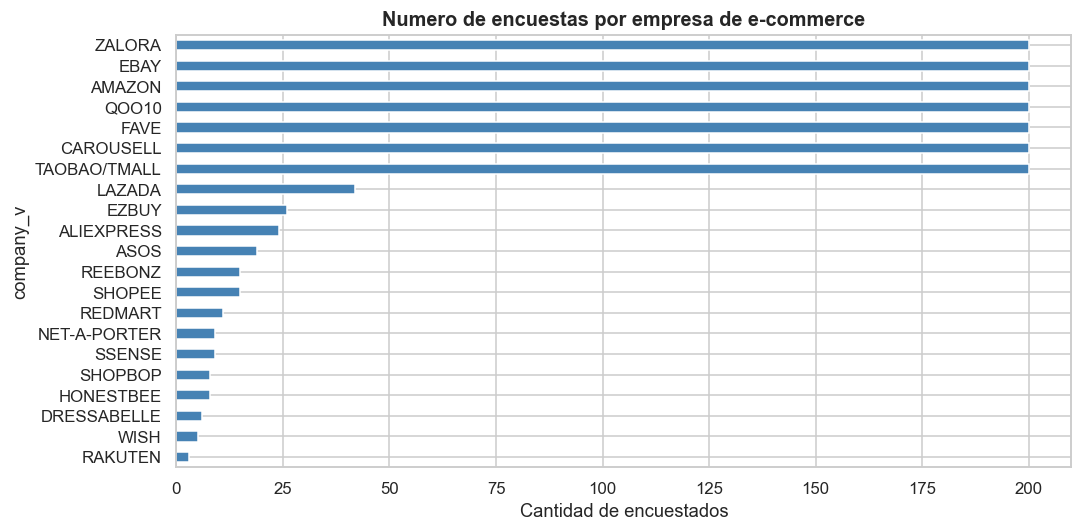

In [7]:
SPECIAL_VALUES = [97, 98, 99]

empresa_counts = df_raw['company_v'].value_counts()
print(f"Total de empresas: {len(empresa_counts)}")
print(empresa_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
empresa_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Numero de encuestas por empresa de e-commerce", fontsize=13, fontweight='bold')
ax.set_xlabel("Cantidad de encuestados")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Resultado:** El dataset incluye 21 empresas. Las 7 principales (Amazon, Zalora, Fave, Qoo10, Carousell, Taobao/Tmall y eBay) tienen exactamente 200 observaciones cada una, garantizando representacion balanceada para el analisis por empresa. El resto son muestras mas pequenas de competidores secundarios. En total hay 1.600 observaciones.


### 2.3 Grupos de variables

Se presenta la taxonomia del dataset segun el diccionario de variables. Conocer la naturaleza de cada variable es fundamental para decidir como tratarlas en el preprocesamiento y en el modelado.

| Grupo | Variables | Tipo |
|-------|-----------|------|
| Percepciones generales | poverq, soverq, pq, satis, repur, recomm, Q19, VN_1009_Q20A | Ordinales (1-10) / Binaria |
| Touchpoints de experiencia | VN_1009_TP01 a VN_1009_TP23 | Ordinales (1-10) |
| Comportamiento de compra | VN_1009_TP20, VN_1009_TP21, VN_1009_TP24, Q9C_P, Q9D | Categoricas / Numericas |
| Sociodemograficas | age, gender, race, educat, pincome, income, marital, house | Ordinales / Categoricas |
| Administrativas | company_v, DOI, VN_1009_TP21_6specify | No se usan en el modelo |


### 2.4 Estadisticos descriptivos

Se calculan los principales estadisticos resumidos para todas las variables numericas. Esto permite identificar rangos, promedios, dispersiones y posibles anomalias antes de cualquier transformacion.


In [8]:
admin_cols = ['company_v', 'DOI', 'VN_1009_TP21_6specify']
num_df = df_raw.drop(columns=admin_cols, errors='ignore').select_dtypes(include='number')
display(num_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
poverq,1600.00,7.57,1.36,2.00,7.00,8.00,8.00,10.00
soverq,1600.00,7.55,1.31,2.00,7.00,8.00,8.00,10.00
pq,1600.00,7.57,1.36,2.00,7.00,8.00,8.00,10.00
satis,1600.00,7.58,1.19,2.00,7.00,8.00,8.00,10.00
repur,1600.00,7.45,1.27,2.00,7.00,7.00,8.00,10.00
recomm,1600.00,7.29,1.36,2.00,7.00,7.00,8.00,10.00
Q19,1600.00,0.25,0.43,0.00,0.00,0.00,0.00,1.00
VN_1009_Q20A,1600.00,7.67,1.24,2.00,7.00,8.00,8.00,10.00
VN_1009_TP01,1600.00,7.86,1.05,3.00,7.00,8.00,9.00,10.00
VN_1009_TP02,1600.00,7.60,1.27,2.00,7.00,8.00,9.00,10.00


**Resultado:** Las variables en escala 1-10 muestran medias entre 7 y 8, con desviaciones estandar bajas (0.9-1.8), lo que confirma el sesgo positivo esperado en encuestas de satisfaccion. La variable Q9D (gasto promedio por visita) tiene una media de 166 SGD con desviacion estandar de 188, indicando alta variabilidad y presencia de valores extremos que requeriran tratamiento. La variable age tiene una distribucion mas uniforme, centrada alrededor de 35 anos.


### 2.5 Calidad de datos: valores especiales y faltantes

Se identifican y cuantifican todos los valores problematicos presentes en el dataset antes de cualquier transformacion. Incluye valores centinela 97, 98, 99 en columnas numericas y espacios en blanco en columnas de texto. Conocer el volumen y patron de los faltantes es esencial para elegir la estrategia de imputacion adecuada.


In [9]:
print("Columnas con valores especiales 97/98/99:")
print()
for col in num_df.columns:
    for sv in SPECIAL_VALUES:
        cnt = (df_raw[col] == sv).sum()
        if cnt > 0:
            pct = cnt / len(df_raw) * 100
            print(f"  {col:<25} | valor={sv} | n={cnt:4d} ({pct:.1f}%)")

print()
print("Columnas de texto con espacios en blanco como faltantes:")
for col in ['VN_1009_TP22', 'VN_1009_TP23', 'pincome']:
    n = (df_raw[col] == ' ').sum()
    pct = n / len(df_raw) * 100
    print(f"  {col:<25} | n={n:4d} ({pct:.1f}%)")

Columnas con valores especiales 97/98/99:

  VN_1009_TP09              | valor=97 | n= 176 (11.0%)
  VN_1009_TP13              | valor=97 | n=   6 (0.4%)
  VN_1009_TP14              | valor=97 | n=  50 (3.1%)
  VN_1009_TP15              | valor=97 | n= 306 (19.1%)
  VN_1009_TP16              | valor=97 | n=   1 (0.1%)
  VN_1009_TP18              | valor=97 | n=  19 (1.2%)
  VN_1009_TP19              | valor=97 | n= 286 (17.9%)
  income                    | valor=97 | n=  92 (5.8%)
  income                    | valor=98 | n=  50 (3.1%)
  childsupp                 | valor=99 | n= 587 (36.7%)

Columnas de texto con espacios en blanco como faltantes:
  VN_1009_TP22              | n= 221 (13.8%)
  VN_1009_TP23              | n= 710 (44.4%)
  pincome                   | n= 196 (12.2%)


**Resultado:** Las columnas con mayor porcentaje de faltantes son VN_1009_TP23 con 44.4% (contacto con el vendedor, que no aplica a quienes no interactuaron), childsupp con 36.7% (alta tasa de rechazo por ser dato personal), VN_1009_TP15 con 19.1% (rastreo de pedido, solo aplica a quienes lo usaron) y VN_1009_TP19 con 17.9% (devoluciones, solo aplica a quienes hicieron devolucion). Estos faltantes son de tipo MNAR (Missing Not At Random): la ausencia de respuesta no es aleatoria sino que depende del propio comportamiento del encuestado, lo que le da un significado interpretativo a la ausencia misma.


### 2.6 Distribucion de variables de satisfaccion

Se grafican los histogramas de las 7 variables de percepcion general, excluyendo los valores especiales. Estos graficos permiten observar la forma de la distribucion, identificar sesgos y detectar si hay pilas de respuestas en algun extremo de la escala.


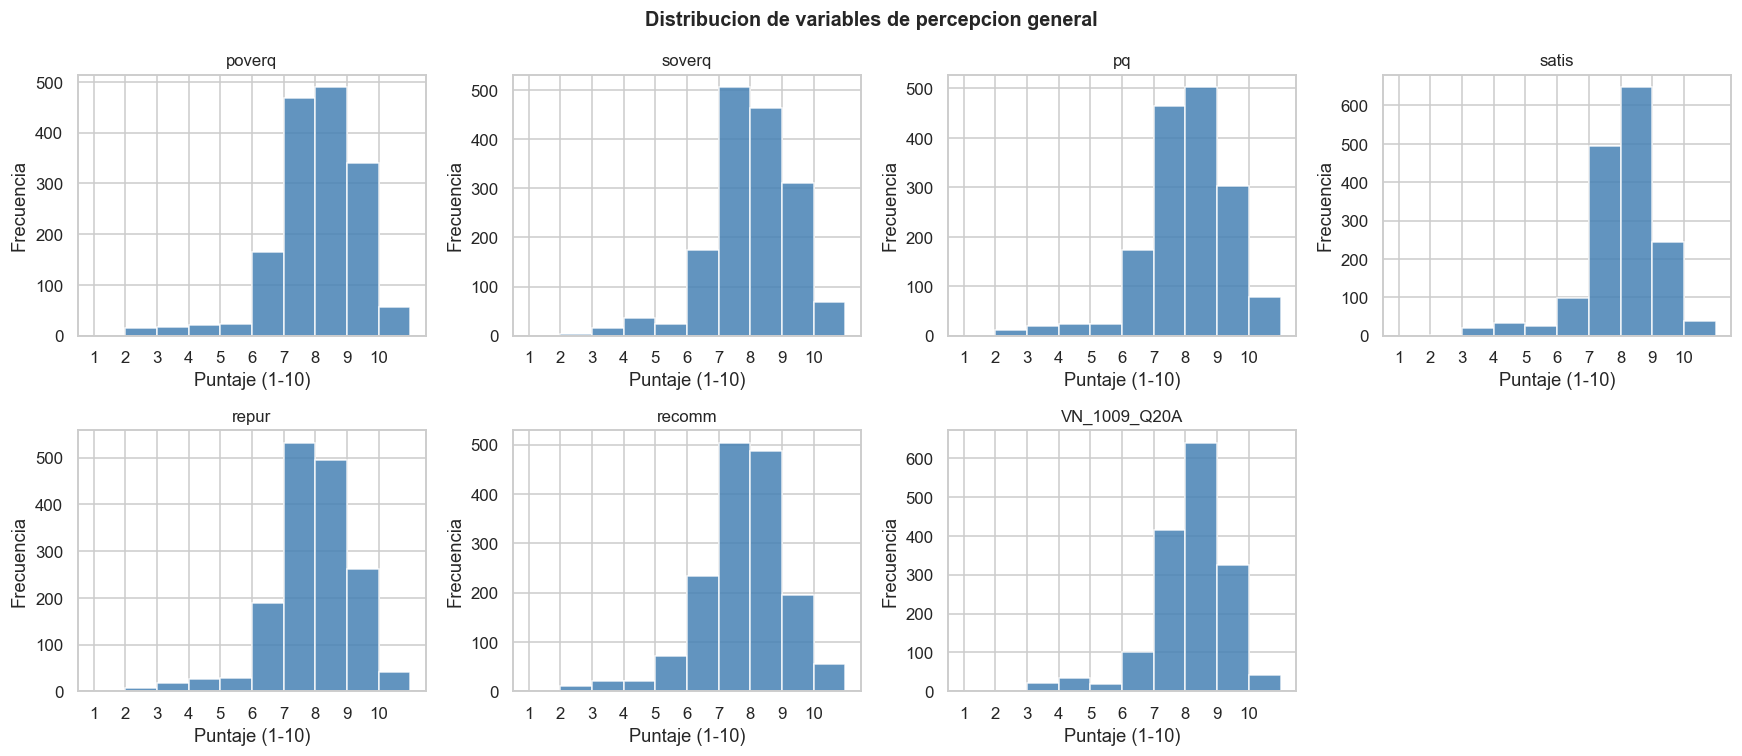

Medianas por variable de satisfaccion:
poverq         8.00
soverq         8.00
pq             8.00
satis          8.00
repur          7.00
recomm         7.00
VN_1009_Q20A   8.00


In [10]:
satisf_cols = ['poverq', 'soverq', 'pq', 'satis', 'repur', 'recomm', 'VN_1009_Q20A']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(satisf_cols):
    vals = df_raw[col][~df_raw[col].isin(SPECIAL_VALUES)]
    axes[i].hist(vals, bins=range(1, 12), color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("Puntaje (1-10)")
    axes[i].set_xticks(range(1, 11))
    axes[i].set_ylabel("Frecuencia")

axes[-1].set_visible(False)
fig.suptitle("Distribucion de variables de percepcion general", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Medianas por variable de satisfaccion:")
print(df_raw[satisf_cols].replace(SPECIAL_VALUES, np.nan).median().round(2).to_string())

**Resultado:** Todas las variables presentan distribucion asimetrica hacia la izquierda: la mayor concentracion de respuestas esta entre 7 y 9, con pocas observaciones en los valores bajos (1-4). Las medianas oscilan entre 7 y 8. Este patron es tipico en encuestas a clientes activos, ya que los usuarios con experiencias muy negativas tienden a abandonar el servicio antes de ser encuestados. Para el clustering, esto implica que las diferencias entre grupos seran sutiles y estaran en matices de la distribucion mas que en diferencias extremas.


### 2.7 Analisis de sesgo: skewness y curtosis
Se va usar dos estos dos estadisticos que nos ayudan a lo siguiente:

### Skewness (asimetría) mide si la distribución de una variable está inclinada hacia un lado:

* Si la mayoría de personas respondió 7, 8, 9 (puntajes altos) y pocos respondieron 1, 2, 3 → la distribución tiene cola hacia la izquierda → skewness negativo.
* En este caso todas las variables de satisfacción tienen skewness negativo porque la mayoría de encuestados puntúa alto.

### Curtosis mide qué tan "apuntada" o "achatada" es la distribución comparada con una distribución normal:

* Curtosis positiva → las respuestas están muy concentradas en pocos valores (distribución apuntada).
* En este caso curtosis positiva significa que casi todos respondieron entre 7 y 9, con muy poca dispersión.

Basicamente nos dice si los datos estan o no distribuidos de forma balanceada. 
Se calculan el coeficiente de asimetria (skewness) y la curtosis de cada variable de satisfaccion para cuantificar el sesgo observado visualmente. Skewness negativo indica cola a la izquierda (mayoria de valores altos); curtosis positiva indica distribucion mas apuntada que la normal (respuestas concentradas en pocos valores).


,Skewness,Curtosis,Interpretacion
Variable,,,
poverq,-1.16,2.81,Sesgo negativo (cola izquierda)
soverq,-0.78,1.56,Sesgo negativo (cola izquierda)
pq,-1.01,2.40,Sesgo negativo (cola izquierda)
satis,-1.16,2.92,Sesgo negativo (cola izquierda)
repur,-0.91,2.18,Sesgo negativo (cola izquierda)
recomm,-0.78,1.65,Sesgo negativo (cola izquierda)
VN_1009_Q20A,-1.27,2.89,Sesgo negativo (cola izquierda)


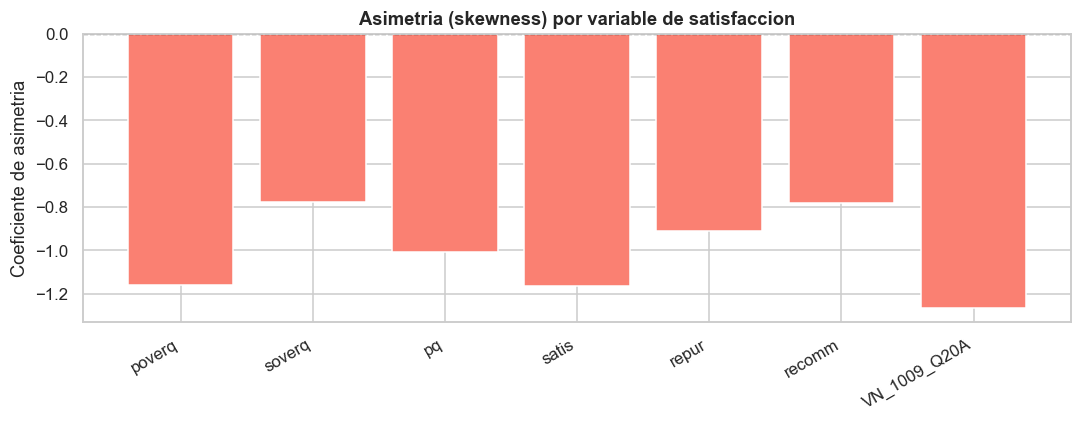

In [11]:
resultados_sesgo = []
for col in satisf_cols:
    vals = df_raw[col].replace(SPECIAL_VALUES, np.nan).dropna()
    s = skew(vals)
    k = kurtosis(vals)
    resultados_sesgo.append({
        'Variable': col,
        'Skewness': round(s, 3),
        'Curtosis': round(k, 3),
        'Interpretacion': 'Sesgo negativo (cola izquierda)' if s < 0 else 'Sesgo positivo'
    })

df_sesgo = pd.DataFrame(resultados_sesgo).set_index('Variable')
display(df_sesgo)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['salmon' if v < 0 else 'steelblue' for v in df_sesgo['Skewness']]
ax.bar(df_sesgo.index, df_sesgo['Skewness'], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Asimetria (skewness) por variable de satisfaccion", fontsize=12, fontweight='bold')
ax.set_ylabel("Coeficiente de asimetria")
ax.set_xticklabels(df_sesgo.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Resultado:** Todas las variables tienen skewness negativo, con valores entre -0.78 (recomm) y -1.27 (VN_1009_Q20A), confirmando la asimetria observada en los histogramas. La curtosis positiva en todos los casos (entre 1.6 y 2.9) indica distribuciones leptocurticas: las respuestas se concentran mas de lo esperado alrededor de los valores altos. La variable VN_1009_Q20A presenta el sesgo mas pronunciado, lo que la convierte en una de las mas discriminantes para separar grupos.


### 2.8 Distribucion de touchpoints de experiencia

Se grafican boxplots de los 19 touchpoints de experiencia (escala 1-10), excluyendo valores especiales. Los boxplots permiten comparar simultaneamente la mediana, dispersion y presencia de valores extremos en cada dimension de la experiencia de compra, facilitando identificar cuales dimensiones tienen mayor variabilidad entre clientes.


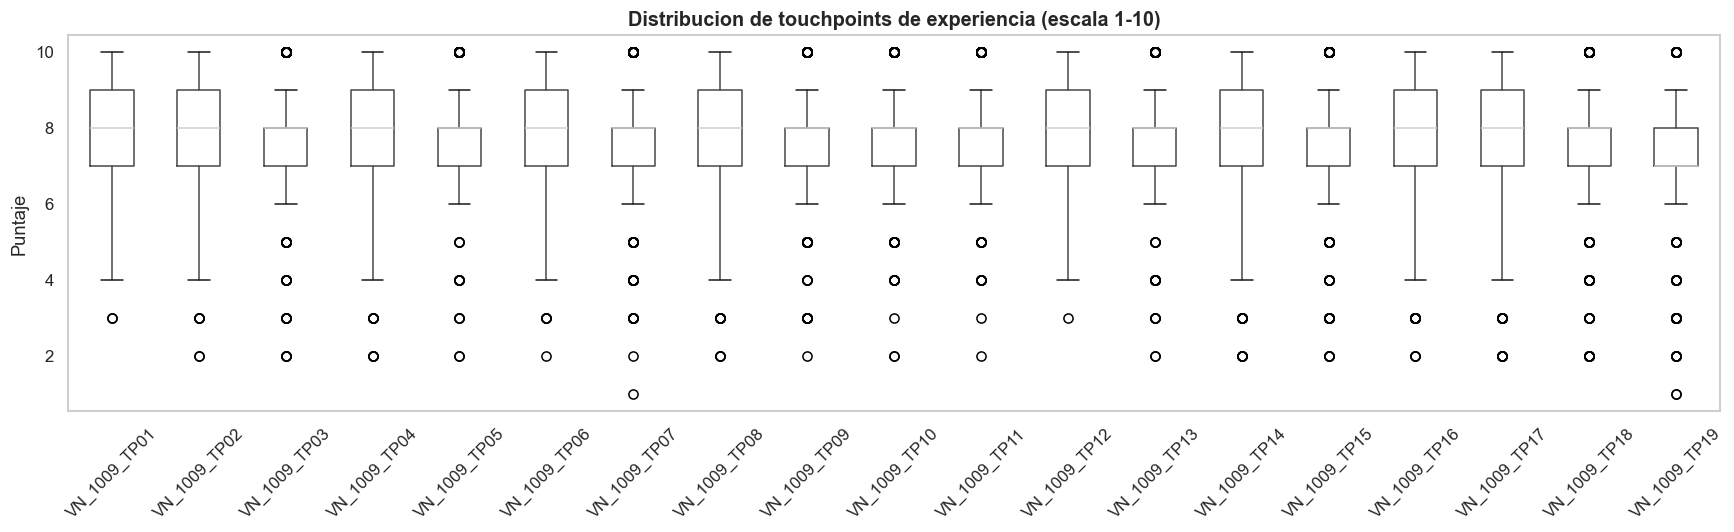

Mediana y desviacion estandar por touchpoint:
              Mediana  Std
VN_1009_TP01     8.00 1.05
VN_1009_TP02     8.00 1.27
VN_1009_TP03     8.00 1.20
VN_1009_TP04     8.00 1.18
VN_1009_TP05     8.00 1.15
VN_1009_TP06     8.00 1.36
VN_1009_TP07     8.00 1.29
VN_1009_TP08     8.00 1.33
VN_1009_TP09     8.00 1.22
VN_1009_TP10     8.00 1.16
VN_1009_TP11     8.00 1.14
VN_1009_TP12     8.00 1.19
VN_1009_TP13     8.00 1.20
VN_1009_TP14     8.00 1.29
VN_1009_TP15     8.00 1.29
VN_1009_TP16     8.00 1.24
VN_1009_TP17     8.00 1.28
VN_1009_TP18     8.00 1.29
VN_1009_TP19     7.00 1.27


In [12]:
tp_cols = [f'VN_1009_TP{str(i).zfill(2)}' for i in range(1, 20)]
tp_cols = [c for c in tp_cols if c in df_raw.columns]

tp_data = df_raw[tp_cols].replace(SPECIAL_VALUES, np.nan)

fig, ax = plt.subplots(figsize=(16, 5))
tp_data.boxplot(ax=ax, rot=45, grid=False)
ax.set_title("Distribucion de touchpoints de experiencia (escala 1-10)", fontsize=13, fontweight='bold')
ax.set_ylabel("Puntaje")
plt.tight_layout()
plt.show()

print("Mediana y desviacion estandar por touchpoint:")
resumen_tp = pd.DataFrame({'Mediana': tp_data.median(), 'Std': tp_data.std()}).round(2)
print(resumen_tp.to_string())

**Resultado:** Los touchpoints tienen medianas entre 7 y 8, consistentes con el patron de satisfaccion general. Los touchpoints con mayor desviacion estandar (mayor caja en el boxplot) son los que mas diferencian a los clientes entre si y son los mas utiles para el clustering. Se observa que los touchpoints relacionados con la logistica (TP15, TP16, TP19) y con solicitudes especiales (TP09) tienen mayor variabilidad, mientras que los de navegacion basica (TP03, TP04) son mas homogeneos.


### 2.9 Perfil de Amazon frente al resto del mercado

Se compara la media de cada touchpoint entre los encuestados de Amazon y los de todas las demas empresas combinadas. Esta comparacion permite identificar las dimensiones especificas donde Amazon supera o esta por debajo del promedio del mercado, lo cual es el corazon del problema de negocio planteado en el caso ISE.


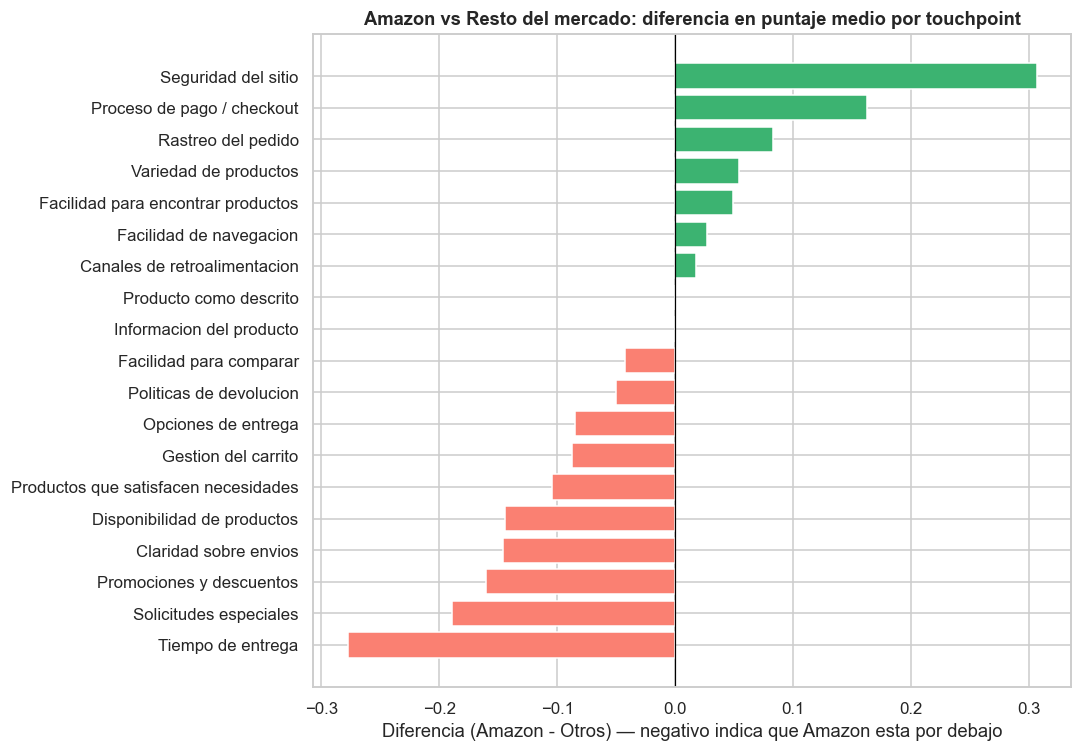

In [13]:
df_tp_comp = df_raw[tp_cols + ['company_v']].copy()
for col in tp_cols:
    df_tp_comp[col] = pd.to_numeric(df_tp_comp[col], errors='coerce').replace(SPECIAL_VALUES, np.nan)

amazon_med = df_tp_comp[df_tp_comp['company_v'] == 'AMAZON'][tp_cols].mean()
otros_med  = df_tp_comp[df_tp_comp['company_v'] != 'AMAZON'][tp_cols].mean()
diff = (amazon_med - otros_med).sort_values()

tp_labels = {
    'VN_1009_TP01': 'Variedad de productos',
    'VN_1009_TP02': 'Productos que satisfacen necesidades',
    'VN_1009_TP03': 'Facilidad de navegacion',
    'VN_1009_TP04': 'Facilidad para encontrar productos',
    'VN_1009_TP05': 'Disponibilidad de productos',
    'VN_1009_TP06': 'Promociones y descuentos',
    'VN_1009_TP07': 'Informacion del producto',
    'VN_1009_TP08': 'Facilidad para comparar',
    'VN_1009_TP09': 'Solicitudes especiales',
    'VN_1009_TP10': 'Gestion del carrito',
    'VN_1009_TP11': 'Proceso de pago / checkout',
    'VN_1009_TP12': 'Seguridad del sitio',
    'VN_1009_TP13': 'Claridad sobre envios',
    'VN_1009_TP14': 'Opciones de entrega',
    'VN_1009_TP15': 'Rastreo del pedido',
    'VN_1009_TP16': 'Tiempo de entrega',
    'VN_1009_TP17': 'Producto como descrito',
    'VN_1009_TP18': 'Canales de retroalimentacion',
    'VN_1009_TP19': 'Politicas de devolucion',
}
diff.index = [tp_labels.get(i, i) for i in diff.index]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['salmon' if v < 0 else 'mediumseagreen' for v in diff.values]
ax.barh(diff.index, diff.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Amazon vs Resto del mercado: diferencia en puntaje medio por touchpoint", fontsize=12, fontweight='bold')
ax.set_xlabel("Diferencia (Amazon - Otros) — negativo indica que Amazon esta por debajo")
plt.tight_layout()
plt.show()

**Resultado:** Amazon presenta una ventaja clara en aspectos tecnicos del sitio: seguridad del sitio web (+0.31 puntos frente al mercado) y proceso de pago/checkout (+0.16 puntos). Sin embargo, tiene debilidades concretas en la dimension logistica: tiempo de entrega (-0.28 puntos), solicitudes especiales (-0.19 puntos), promociones y descuentos (-0.16 puntos) y claridad sobre envios (-0.15 puntos). Este perfil tiene sentido en el contexto de Singapur, donde competidores locales como Qoo10 y Lazada ofrecen entregas en el mismo dia y descuentos agresivos. Amazon, con infraestructura global, aun no ha adaptado su propuesta de valor a las expectativas del mercado local. Este diagnostico orientara la interpretacion de los clusters en la siguiente etapa.


### 2.10 Satisfaccion media por empresa

Se calcula y grafica el puntaje promedio de satisfaccion general (variable satis) por empresa. Esto contextualiza la posicion competitiva de Amazon dentro del mercado de e-commerce en Singapur y permite establecer una referencia comparativa para la interpretacion de los clusters.


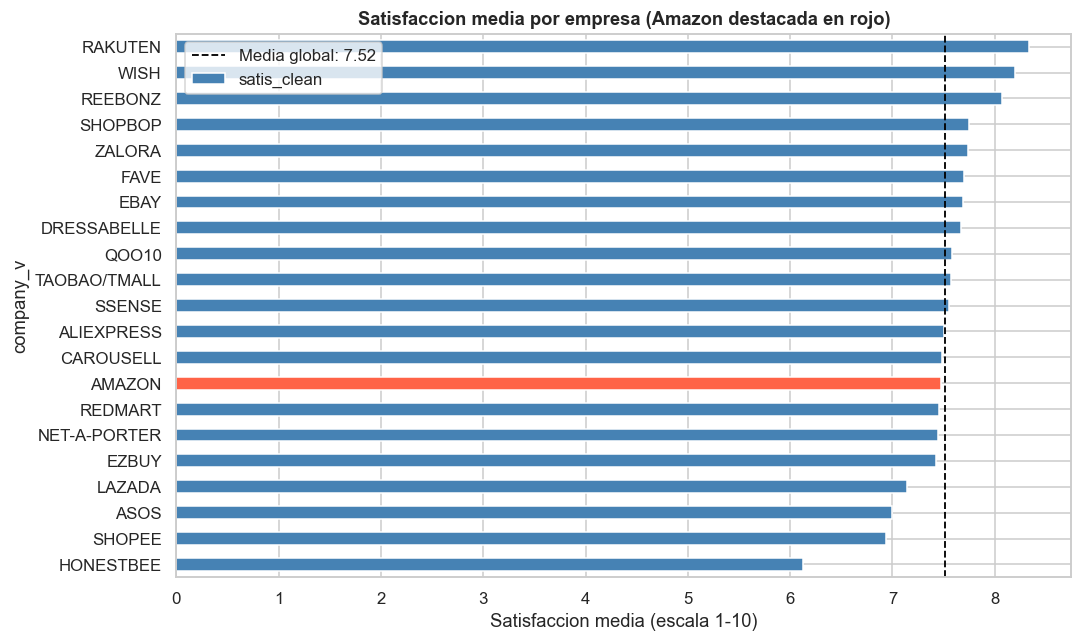

,Empresa,Satisfaccion_media
Posicion,,
1,HONESTBEE,6.12
2,SHOPEE,6.93
3,ASOS,7.00
4,LAZADA,7.14
5,EZBUY,7.42
6,NET-A-PORTER,7.44
7,REDMART,7.45
8,AMAZON,7.48
9,CAROUSELL,7.48


In [15]:
df_satis_emp = df_raw.copy()
df_satis_emp['satis_clean'] = df_raw['satis'].replace(SPECIAL_VALUES, np.nan)
satis_empresa = df_satis_emp.groupby('company_v')['satis_clean'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['tomato' if c == 'AMAZON' else 'steelblue' for c in satis_empresa.index]
satis_empresa.plot(kind='barh', ax=ax, color=colores, edgecolor='white')
ax.axvline(satis_empresa.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Media global: {satis_empresa.mean():.2f}')
ax.set_title("Satisfaccion media por empresa (Amazon destacada en rojo)", fontsize=12, fontweight='bold')
ax.set_xlabel("Satisfaccion media (escala 1-10)")
ax.legend()
plt.tight_layout()
plt.show()

ranking = satis_empresa.reset_index()
ranking.columns = ['Empresa', 'Satisfaccion_media']
ranking['Posicion'] = range(1, len(ranking)+1)
ranking['Satisfaccion_media'] = ranking['Satisfaccion_media'].round(2)
display(ranking.set_index('Posicion'))

**Resultado:** Amazon obtiene una satisfaccion media de 7.48, ubicandola en la posicion 8 de 21 empresas. No es la peor del mercado (Honeybee: 6.12, Shopee: 6.93), pero esta por debajo de lo esperado para una empresa de su tamano y reconocimiento global. Marcas especializadas como Rakuten (8.33), Reebonz (8.07) y Wish (8.20) la superan claramente. La paradoja es que Amazon no falla en terminos absolutos, sino que dado su posicionamiento de marca premium, se esperaria que liderara el ranking. El analisis de clustering buscara identificar que perfiles de clientes explican esta brecha.


### 2.11 Distribucion de variables categoricas

Se grafican los conteos de categorias para las principales variables nominales, excluyendo valores especiales. Permite entender la composicion demografica y de comportamiento de los encuestados.


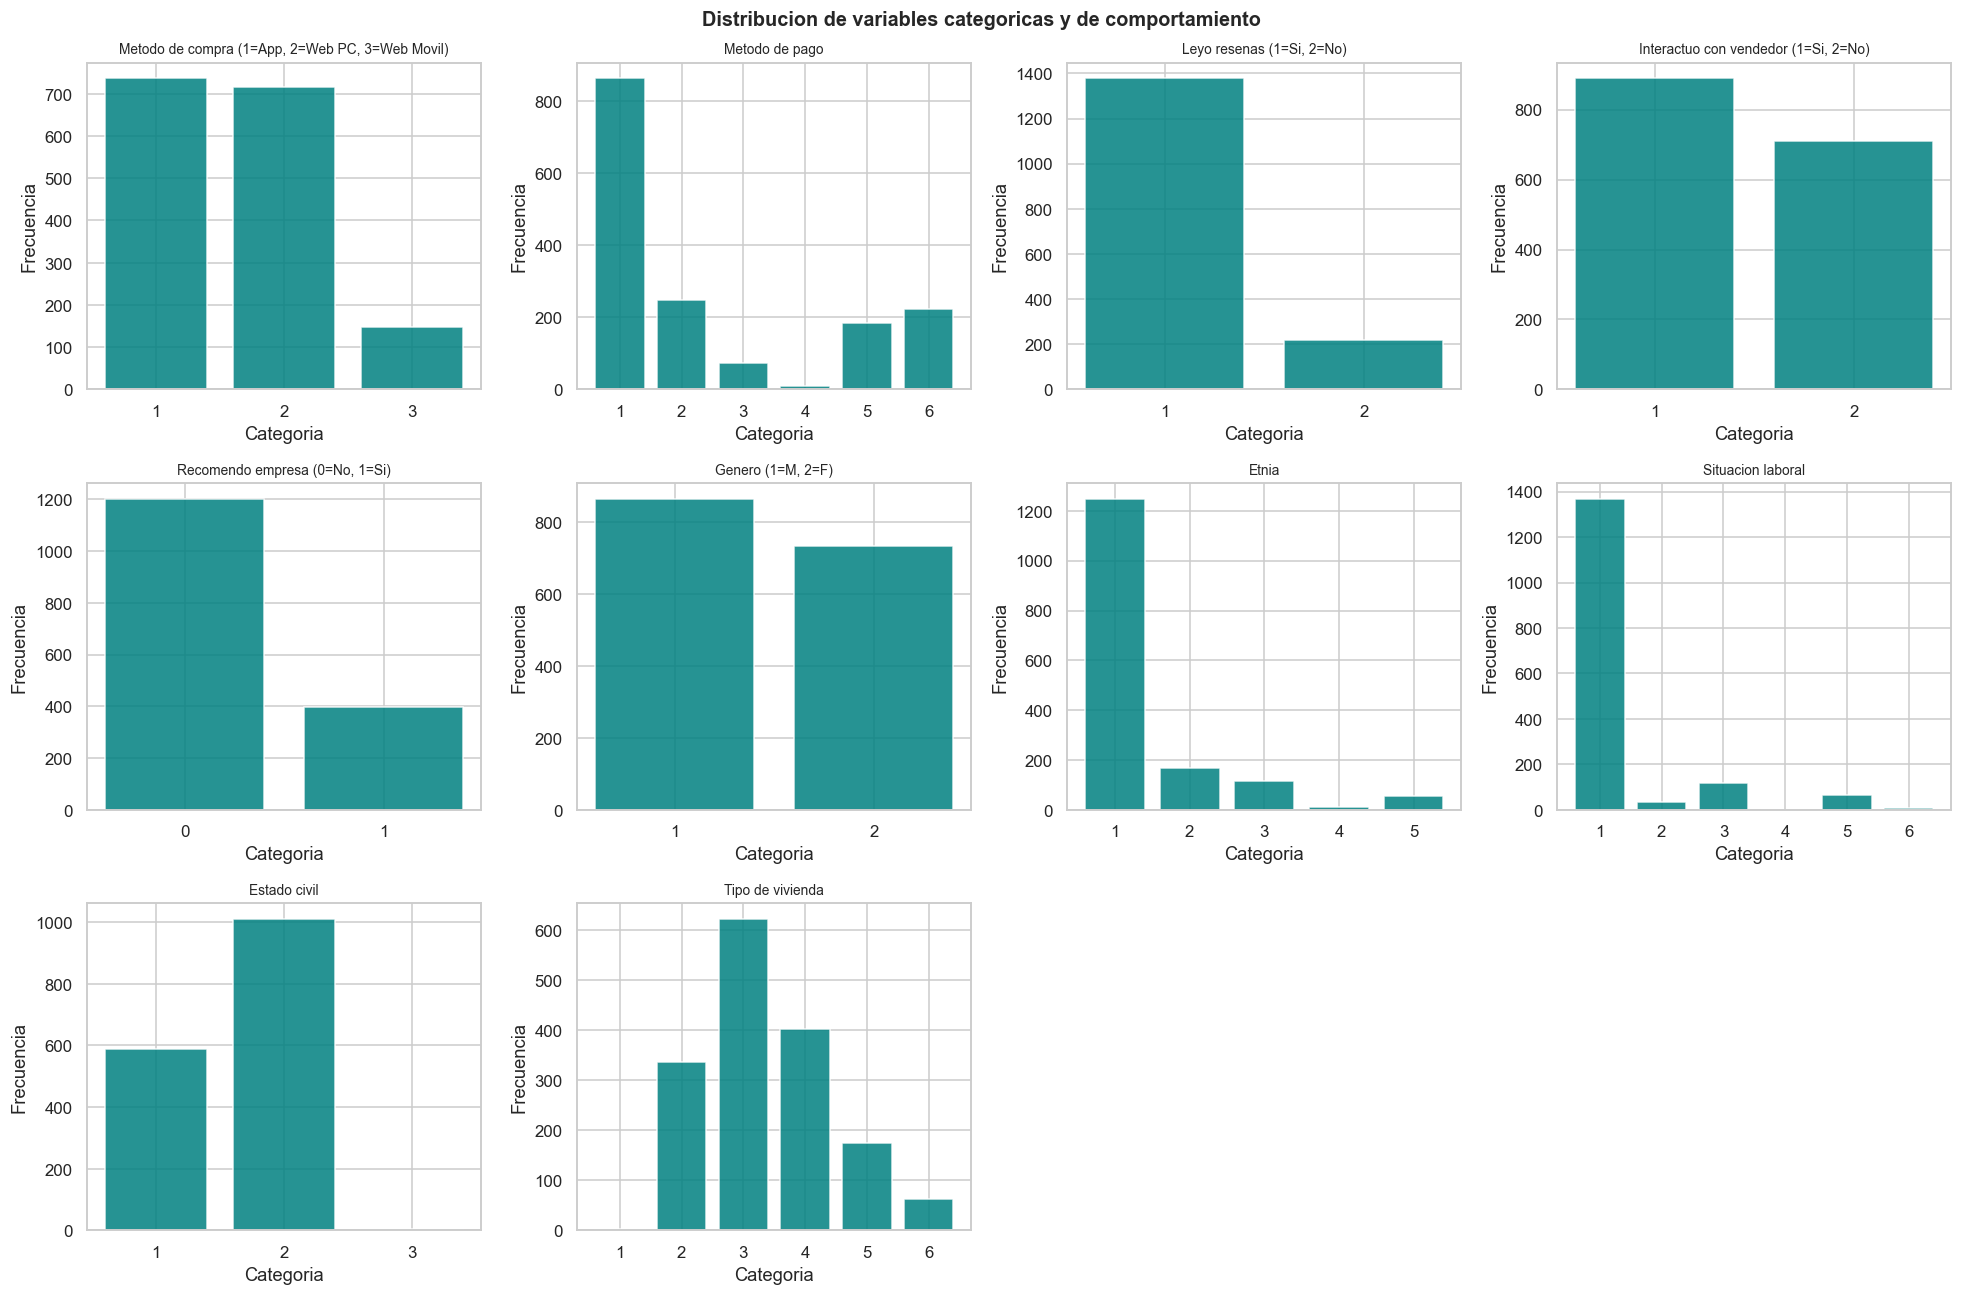

In [16]:
cat_info = {
    'VN_1009_TP20': 'Metodo de compra (1=App, 2=Web PC, 3=Web Movil)',
    'VN_1009_TP21': 'Metodo de pago',
    'VN_1009_TP24_1': 'Leyo resenas (1=Si, 2=No)',
    'VN_1009_TP24_2': 'Interactuo con vendedor (1=Si, 2=No)',
    'Q19': 'Recomendo empresa (0=No, 1=Si)',
    'gender': 'Genero (1=M, 2=F)',
    'race': 'Etnia',
    'work': 'Situacion laboral',
    'marital': 'Estado civil',
    'house': 'Tipo de vivienda',
}

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, (col, titulo) in enumerate(cat_info.items()):
    vals = df_raw[col].replace(SPECIAL_VALUES, np.nan).dropna()
    counts = vals.value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color='teal', edgecolor='white', alpha=0.85)
    axes[i].set_title(titulo, fontsize=9)
    axes[i].set_xlabel("Categoria")
    axes[i].set_ylabel("Frecuencia")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribucion de variables categoricas y de comportamiento", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Resultado:** La mayoria de los encuestados realiza sus compras a traves de la aplicacion movil (categoria 1 en TP20), lo que refleja el alto nivel de penetracion de smartphones en Singapur. El metodo de pago mas frecuente es tarjeta de credito. Solo el 25% recomendo la empresa a familiares o amigos en los ultimos 3 meses (Q19), lo cual es consistente con la posicion media de Amazon en el ranking de satisfaccion. La muestra tiene una leve predominancia masculina y esta compuesta principalmente por trabajadores a tiempo completo.


### 2.12 Variables numericas continuas: edad y gasto

Se analizan las distribuciones de age (edad en anos), Q9C_P (numero de compras en los ultimos 6 meses) y Q9D (gasto promedio por visita en dolares de Singapur). Estas variables tienen rangos muy distintos a las escalas Likert y pueden contener outliers que distorsionen el analisis.


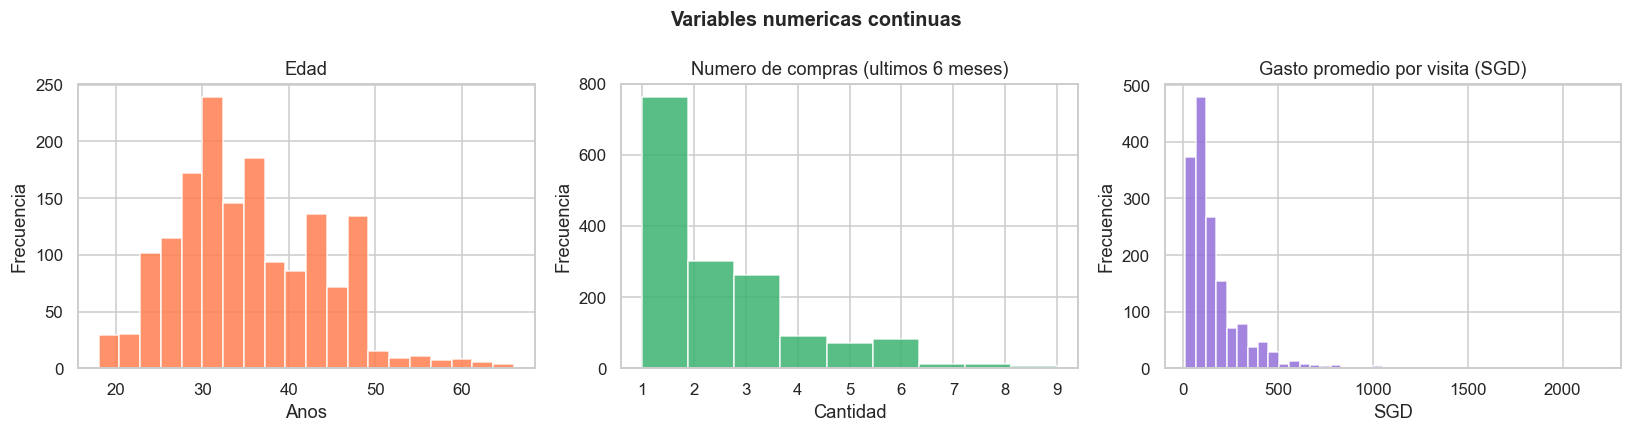

Edad   - media: 35.3, std: 8.5, rango: [18, 66]
Q9C_P  - media: 2.25, std: 1.63, rango: [1, 9]
Q9D    - media: 166.6, std: 181.4, rango: [10, 2200]


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_raw['age'], bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[0].set_title("Edad")
axes[0].set_xlabel("Anos")

axes[1].hist(df_raw['Q9C_P'], bins=9, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title("Numero de compras (ultimos 6 meses)")
axes[1].set_xlabel("Cantidad")

gasto = df_raw['Q9D'].replace(SPECIAL_VALUES, np.nan).dropna()
axes[2].hist(gasto, bins=40, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[2].set_title("Gasto promedio por visita (SGD)")
axes[2].set_xlabel("SGD")

for ax in axes:
    ax.set_ylabel("Frecuencia")

fig.suptitle("Variables numericas continuas", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Edad   - media: {df_raw['age'].mean():.1f}, std: {df_raw['age'].std():.1f}, rango: [{df_raw['age'].min()}, {df_raw['age'].max()}]")
print(f"Q9C_P  - media: {df_raw['Q9C_P'].mean():.2f}, std: {df_raw['Q9C_P'].std():.2f}, rango: [{df_raw['Q9C_P'].min()}, {df_raw['Q9C_P'].max()}]")
print(f"Q9D    - media: {gasto.mean():.1f}, std: {gasto.std():.1f}, rango: [{gasto.min()}, {gasto.max()}]")

**Resultado:** La edad tiene una distribucion relativamente uniforme entre 18 y 66 anos, centrada alrededor de 35. El numero de compras (Q9C_P) esta fuertemente sesgado a la derecha: la mayoria realizo entre 1 y 3 compras en 6 meses, con muy pocos compradores frecuentes. El gasto promedio (Q9D) presenta el sesgo mas pronunciado, con una media de 166 SGD pero valores extremos que llegan hasta 2.200 SGD. Esta variable requiere tratamiento de outliers antes del modelado.


### 2.13 Correlaciones de Spearman entre satisfaccion y touchpoints

Se calcula la matriz de correlacion de Spearman entre todas las variables de satisfaccion y touchpoints. Se usa Spearman en lugar de Pearson porque las variables son ordinales: Spearman mide asociacion monotonica sin asumir normalidad ni linealidad, siendo el metodo correcto para escalas Likert.


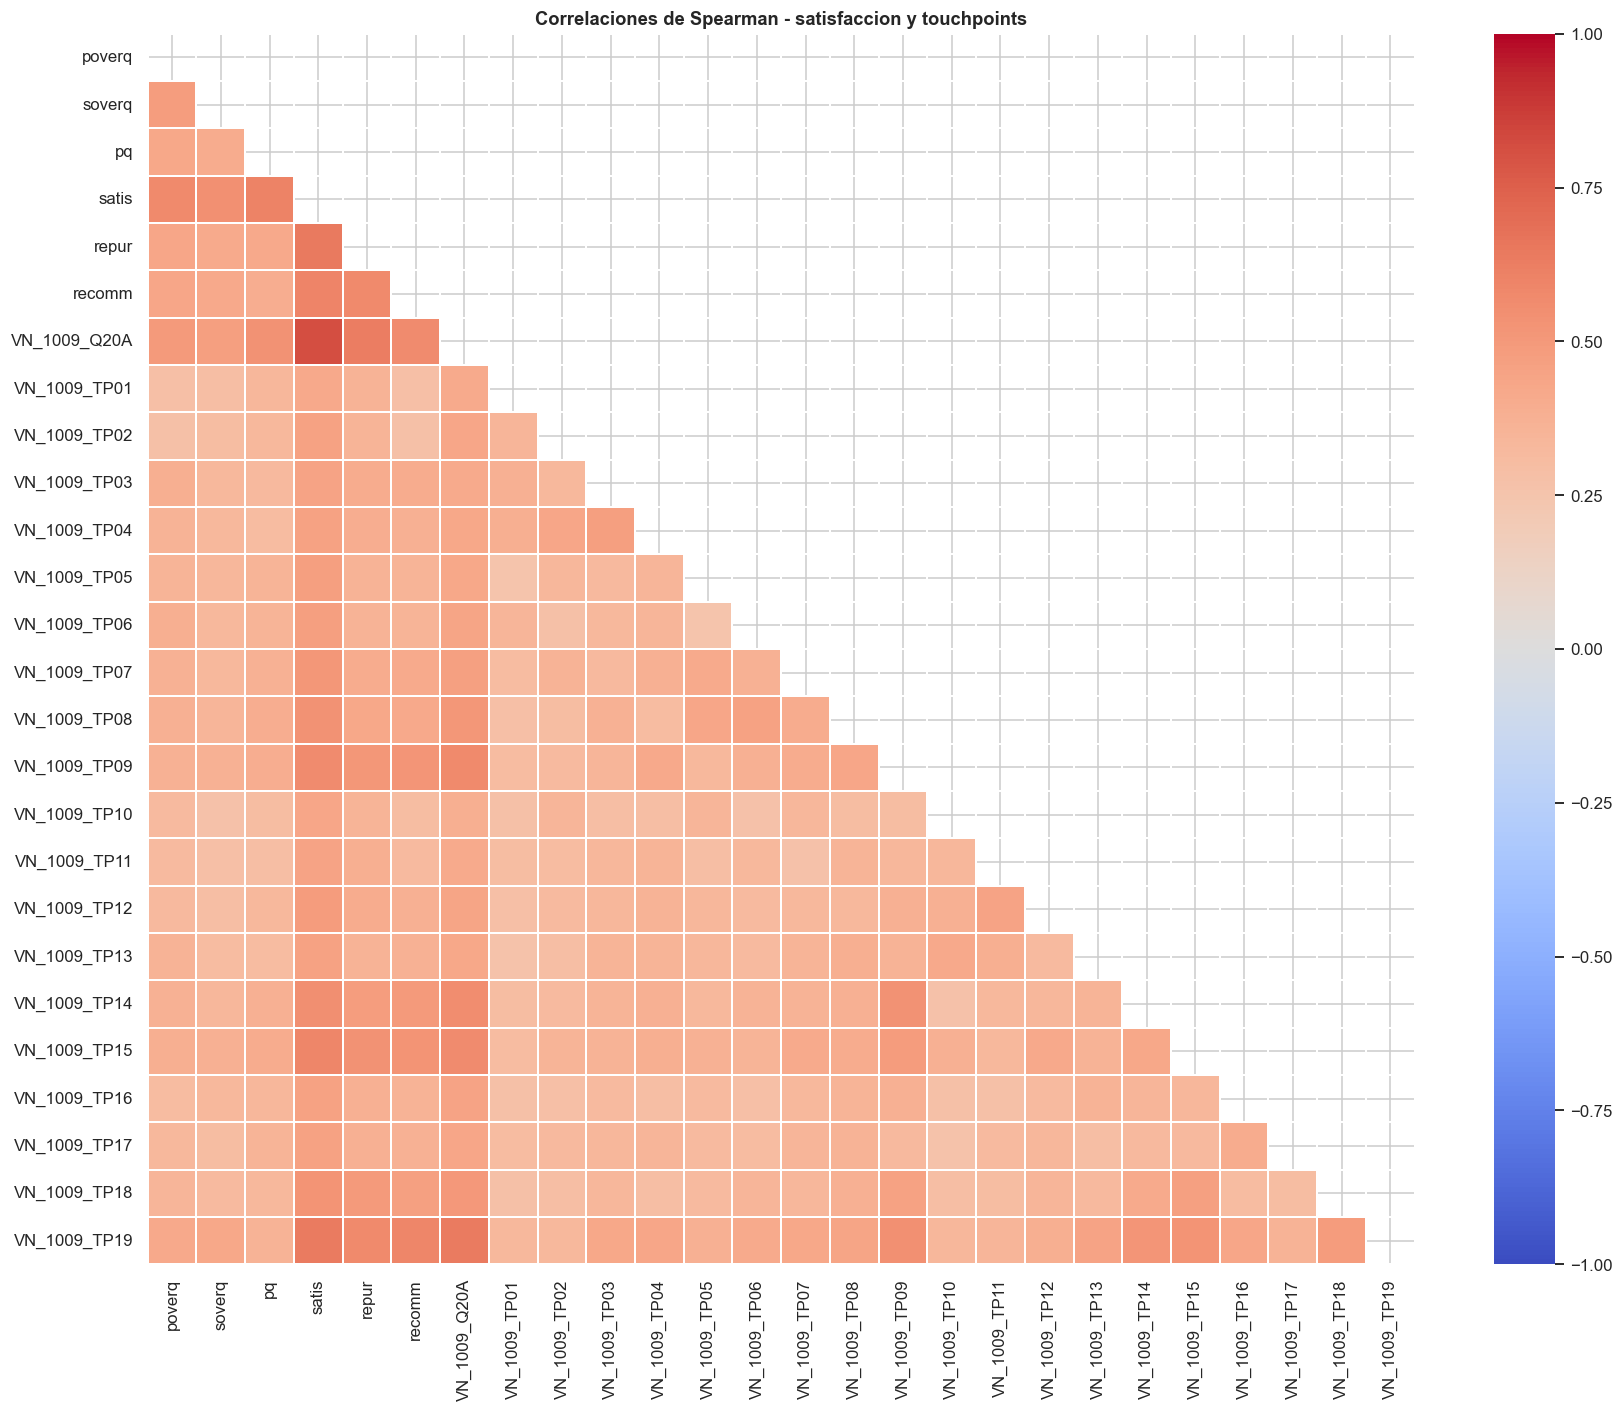

Top 8 correlaciones con satis (satisfaccion general):
VN_1009_Q20A   0.82
repur          0.65
VN_1009_TP19   0.63
pq             0.61
recomm         0.60
VN_1009_TP15   0.59
poverq         0.58
VN_1009_TP09   0.56


In [18]:
all_likert = satisf_cols + tp_cols
likert_data = df_raw[all_likert].replace(SPECIAL_VALUES, np.nan)
corr = likert_data.corr(method='spearman')

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlaciones de Spearman - satisfaccion y touchpoints", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 8 correlaciones con satis (satisfaccion general):")
print(corr['satis'].drop('satis').sort_values(ascending=False).head(8).round(3).to_string())

**Resultado:** Las variables de satisfaccion general (satis, poverq, soverq, pq) estan fuertemente correlacionadas entre si (Spearman > 0.70), indicando que miden constructos muy relacionados. Entre los touchpoints, se identifican dos bloques: (1) navegacion y catalogo (TP01-TP08) y (2) entrega y post-compra (TP13-TP19), con correlaciones internas altas. Esta estructura de bloques es una senal positiva para PCA: sugiere que la tecnica podra reducir efectivamente la dimensionalidad agrupando variables redundantes en componentes latentes.


### 2.14 Asociaciones entre variables categoricas: V de Cramer

Se calcula el estadistico V de Cramer para todos los pares de variables categoricas. Este estadistico es el equivalente a la correlacion para variables nominales: mide la fuerza de asociacion en tablas de contingencia con valores entre 0 (sin asociacion) y 1 (asociacion perfecta). Se interpreta como: V < 0.10 asociacion nula, 0.10-0.30 debil a moderada, mayor a 0.30 moderada a fuerte.


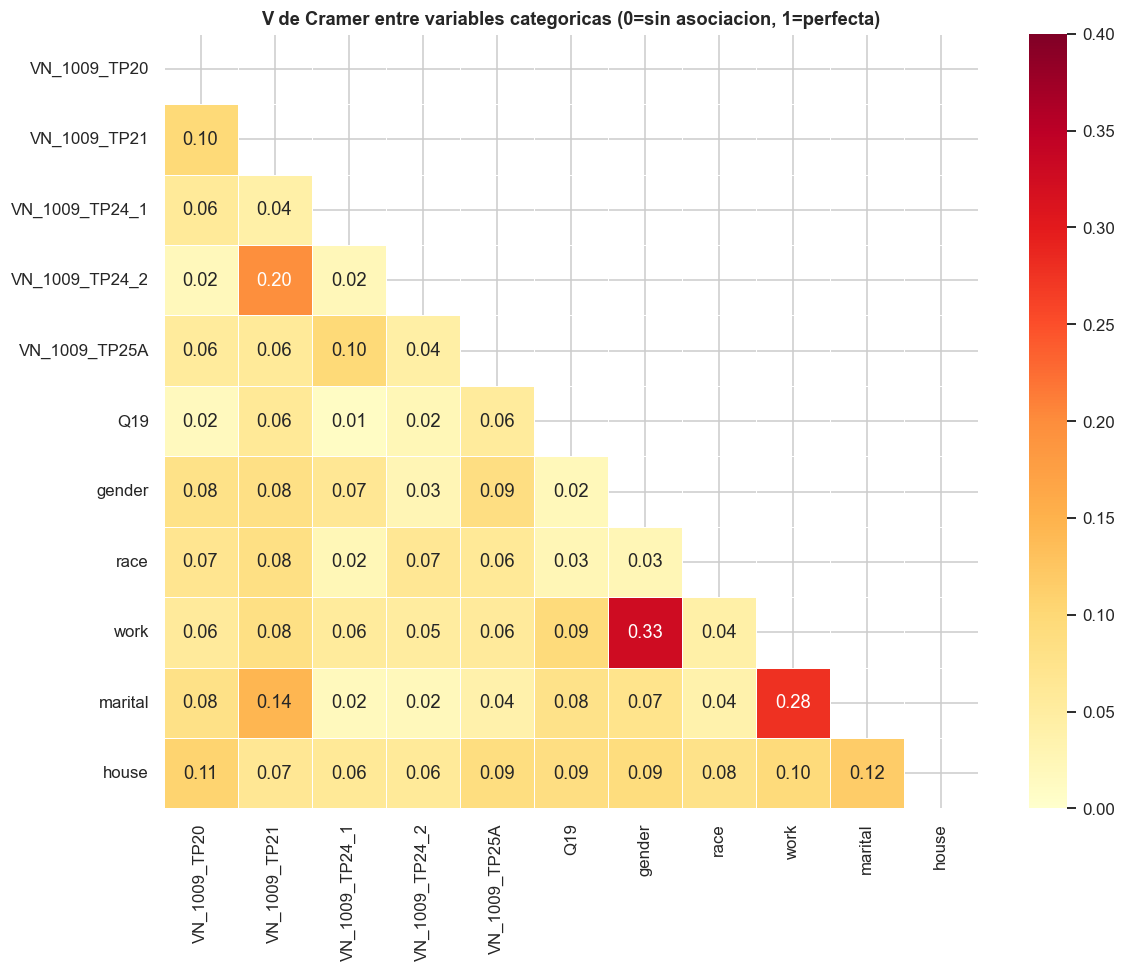

Top 10 pares con mayor asociacion:


,Variable A,Variable B,V de Cramer
0,gender,work,0.33
1,work,marital,0.28
2,VN_1009_TP21,VN_1009_TP24_2,0.20
3,VN_1009_TP21,marital,0.14
4,marital,house,0.12
5,VN_1009_TP20,house,0.11
6,VN_1009_TP24_1,VN_1009_TP25A,0.10
7,VN_1009_TP20,VN_1009_TP21,0.10
8,work,house,0.10
9,Q19,work,0.09


In [19]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    phi2 = chi2 / n
    r_adj = r - (r - 1)**2 / (n - 1)
    k_adj = k - (k - 1)**2 / (n - 1)
    v = np.sqrt(phi2 / min(r_adj - 1, k_adj - 1))
    return max(0, round(v, 3))

cat_vars = ['VN_1009_TP20', 'VN_1009_TP21', 'VN_1009_TP24_1', 'VN_1009_TP24_2',
            'VN_1009_TP25A', 'Q19', 'gender', 'race', 'work', 'marital', 'house']

n = len(cat_vars)
cramer_matrix = pd.DataFrame(np.zeros((n, n)), index=cat_vars, columns=cat_vars)

for i, a in enumerate(cat_vars):
    for j, b in enumerate(cat_vars):
        if i != j:
            d = df_raw[[a, b]].replace(SPECIAL_VALUES, np.nan).dropna()
            if len(d) > 20:
                cramer_matrix.loc[a, b] = cramers_v(d[a], d[b])

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(cramer_matrix, dtype=bool))
sns.heatmap(cramer_matrix, mask=mask, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=0.4, ax=ax, linewidths=0.5)
ax.set_title("V de Cramer entre variables categoricas (0=sin asociacion, 1=perfecta)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

resultados = []
for i, a in enumerate(cat_vars):
    for b in cat_vars[i+1:]:
        v = cramer_matrix.loc[a, b]
        if v > 0:
            resultados.append({'Variable A': a, 'Variable B': b, 'V de Cramer': v})

df_cramer = pd.DataFrame(resultados).sort_values('V de Cramer', ascending=False)
print("Top 10 pares con mayor asociacion:")
display(df_cramer.head(10).reset_index(drop=True))

**Resultado:** La asociacion mas fuerte es entre gender y work (V=0.327), reflejando diferencias de genero en la participacion laboral: las mujeres tienen mayor proporcion en trabajo de tiempo parcial, mientras los hombres dominan el tiempo completo. Le sigue work con marital (V=0.277): personas casadas tienden a estar en tiempo completo. En general, las asociaciones entre variables de comportamiento de compra y variables sociodemograficas son bajas (V < 0.20), lo que indica que los patrones de compra no estan determinados por una sola caracteristica sino por combinaciones de ellas. Esto valida el uso de clustering multivariado.


## 3. Preprocesamiento de Datos

A partir del diagnostico del EDA, se aplican las siguientes transformaciones en el orden indicado:

1. Eliminar columnas administrativas sin valor para el modelo
2. Convertir valores especiales (97, 98, 99) y espacios en blanco a NaN
3. Imputar valores faltantes
4. Tratar outliers en variables continuas
5. Definir tipos de variables para el modelo
6. Codificar variables categoricas nominales (One-Hot Encoding)
7. Escalar variables continuas y ordinales (StandardScaler)


### 3.1 Eliminar columnas administrativas

In [20]:
drop_cols = ['company_v', 'DOI', 'VN_1009_TP21_6specify']
df = df_raw.drop(columns=drop_cols, errors='ignore').copy()
print(f"Dimensiones tras eliminar administrativas: {df.shape}")
print(f"Columnas eliminadas: {drop_cols}")

Dimensiones tras eliminar administrativas: (1600, 46)
Columnas eliminadas: ['company_v', 'DOI', 'VN_1009_TP21_6specify']


**Justificacion:** company_v es un identificador de empresa que no representa una caracteristica del cliente; incluirlo generaria clusters que simplemente separan empresas en lugar de perfiles de clientes. DOI es una fecha administrativa y VN_1009_TP21_6specify es un campo de texto libre sin valor cuantitativo.


### 3.2 Conversion de valores especiales a NaN

In [21]:
special_cols_map = {
    'VN_1009_TP09': [97], 'VN_1009_TP13': [97], 'VN_1009_TP14': [97],
    'VN_1009_TP15': [97], 'VN_1009_TP16': [97], 'VN_1009_TP18': [97],
    'VN_1009_TP19': [97], 'income': [97, 98], 'childsupp': [99],
}

for col, values in special_cols_map.items():
    before = df[col].isin(values).sum()
    df[col] = df[col].replace(values, np.nan)
    print(f"  {col:<25} -> {before} valores especiales -> NaN")

for col in ['VN_1009_TP22', 'VN_1009_TP23']:
    df[col] = pd.to_numeric(df[col].replace(' ', np.nan), errors='coerce')
    print(f"  {col:<25} -> espacios en blanco -> NaN")

df['pincome'] = pd.to_numeric(df['pincome'].replace({' ': np.nan, 98: np.nan}), errors='coerce')
print(f"  {'pincome':<25} -> espacios y valor 98 -> NaN")

print()
missing = df.isnull().sum()
print("Valores faltantes por columna (solo columnas con al menos uno):")
print(missing[missing > 0].sort_values(ascending=False).to_string())

  VN_1009_TP09              -> 176 valores especiales -> NaN
  VN_1009_TP13              -> 6 valores especiales -> NaN
  VN_1009_TP14              -> 50 valores especiales -> NaN
  VN_1009_TP15              -> 306 valores especiales -> NaN
  VN_1009_TP16              -> 1 valores especiales -> NaN
  VN_1009_TP18              -> 19 valores especiales -> NaN
  VN_1009_TP19              -> 286 valores especiales -> NaN
  income                    -> 142 valores especiales -> NaN
  childsupp                 -> 587 valores especiales -> NaN
  VN_1009_TP22              -> espacios en blanco -> NaN
  VN_1009_TP23              -> espacios en blanco -> NaN
  pincome                   -> espacios y valor 98 -> NaN

Valores faltantes por columna (solo columnas con al menos uno):
VN_1009_TP23    710
childsupp       587
VN_1009_TP15    306
VN_1009_TP19    286
pincome         240
VN_1009_TP22    221
VN_1009_TP09    176
income          142
VN_1009_TP14     50
VN_1009_TP18     19
VN_1009_TP13      6


**Justificacion:** Los valores 97, 98 y 99 no representan puntajes reales en la escala 1-10; son codigos de no-respuesta. Mantenerlos en el dataset distorsionaria las medias, desviaciones estandar y distancias utilizadas por los algoritmos de clustering y reduccion de dimensionalidad. Su conversion a NaN es el primer paso obligatorio antes de cualquier analisis.


### 3.3 Imputacion de valores faltantes

In [22]:
ordinal_1_10 = (
    ['poverq', 'soverq', 'pq', 'satis', 'repur', 'recomm', 'VN_1009_Q20A'] +
    [f'VN_1009_TP{str(i).zfill(2)}' for i in list(range(1, 20)) + [22, 23]]
)
ordinal_1_10 = [c for c in ordinal_1_10 if c in df.columns]

categoricas = ['VN_1009_TP20', 'VN_1009_TP21', 'VN_1009_TP24_1', 'VN_1009_TP24_2',
               'VN_1009_TP25A', 'Q19', 'gender', 'race', 'work', 'marital', 'house',
               'educat', 'childsupp', 'pincome', 'income']
categoricas = [c for c in categoricas if c in df.columns]

print("=== Imputacion por mediana (variables Likert 1-10) ===")
for col in ordinal_1_10:
    if df[col].isnull().sum() > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f"  {col:<25} -> mediana = {med:.1f}")

print()
print("=== Imputacion por moda (variables categoricas) ===")
for col in categoricas:
    if df[col].isnull().sum() > 0:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)
        print(f"  {col:<25} -> moda = {moda}")

print()
print(f"Valores faltantes restantes: {df.isnull().sum().sum()}")

=== Imputacion por mediana (variables Likert 1-10) ===
  VN_1009_TP09              -> mediana = 8.0
  VN_1009_TP13              -> mediana = 8.0
  VN_1009_TP14              -> mediana = 8.0
  VN_1009_TP15              -> mediana = 8.0
  VN_1009_TP16              -> mediana = 8.0
  VN_1009_TP18              -> mediana = 8.0
  VN_1009_TP19              -> mediana = 7.0
  VN_1009_TP22              -> mediana = 8.0
  VN_1009_TP23              -> mediana = 8.0

=== Imputacion por moda (variables categoricas) ===
  childsupp                 -> moda = 3.0
  pincome                   -> moda = 4.0
  income                    -> moda = 5.0

Valores faltantes restantes: 0


**Justificacion:** Para variables Likert se usa la mediana porque es robusta ante la asimetria negativa observada en el EDA: no se ve afectada por los pocos valores bajos y preserva el caracter ordinal de la escala. Para variables categoricas se usa la moda, que asigna la categoria mas frecuente sin crear categorias artificiales. No se emplean metodos mas complejos como KNN o MICE porque en un analisis exploratorio no supervisado introducen el riesgo de generar estructura artificial que podria ser confundida con patrones reales en el clustering.


### 3.4 Deteccion y tratamiento de outliers

age: 12 outliers extremos (|z| > 3)
  Rango original:            [18.0, 66.0]
  Rango post-winsorizacion:  [19.0, 59.0]

Q9D: 29 outliers extremos (|z| > 3)
  Rango original:            [10.0, 2200.0]
  Rango post-winsorizacion:  [20.0, 900.0]



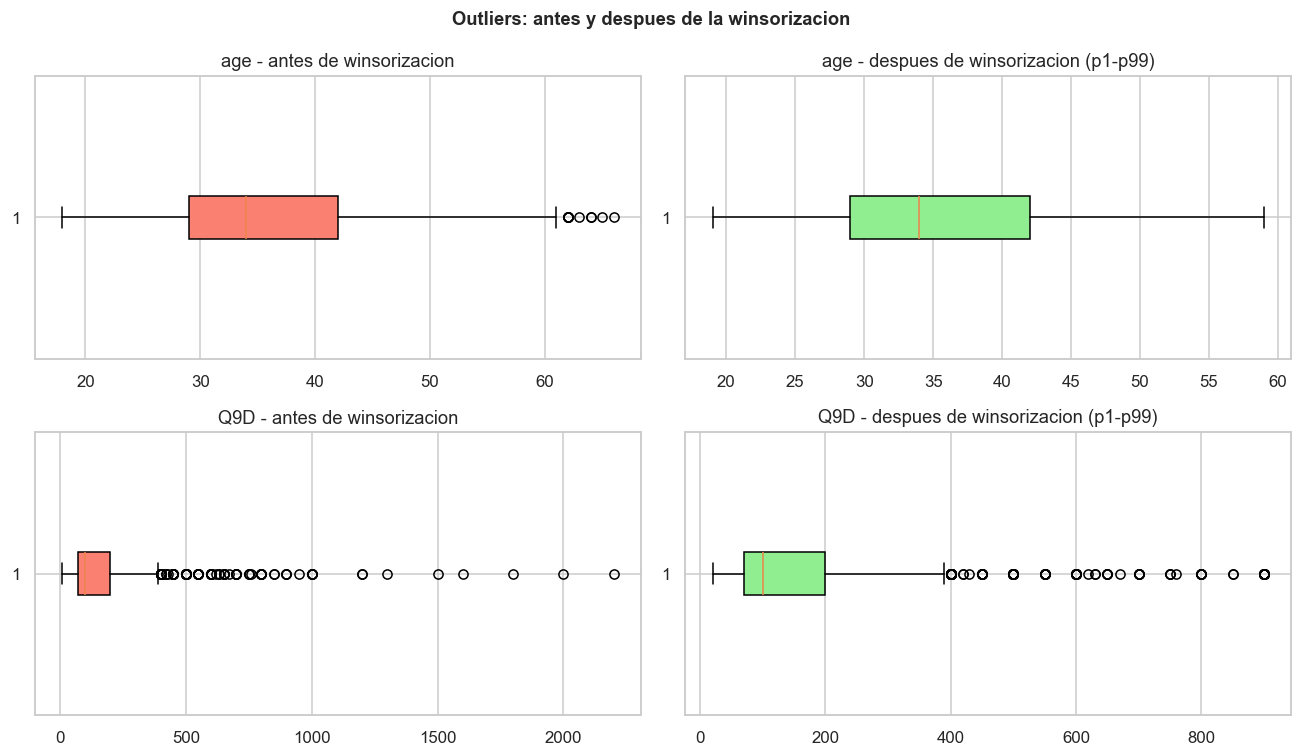

In [23]:
continuas_outlier = ['age', 'Q9D']

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for i, col in enumerate(continuas_outlier):
    axes[i*2].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                     boxprops=dict(facecolor='salmon'))
    axes[i*2].set_title(f"{col} - antes de winsorizacion")

    z = np.abs(zscore(df[col].dropna()))
    n_out = (z > 3).sum()
    p1  = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    print(f"{col}: {n_out} outliers extremos (|z| > 3)")
    print(f"  Rango original:            [{df[col].min():.1f}, {df[col].max():.1f}]")
    df[col] = df[col].clip(lower=p1, upper=p99)
    print(f"  Rango post-winsorizacion:  [{df[col].min():.1f}, {df[col].max():.1f}]")
    print()

    axes[i*2+1].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightgreen'))
    axes[i*2+1].set_title(f"{col} - despues de winsorizacion (p1-p99)")

fig.suptitle("Outliers: antes y despues de la winsorizacion", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Justificacion:** Se aplica winsorizacion (recorte al percentil 1 y 99) en lugar de eliminar filas porque en encuestas cada observacion es valiosa y la eliminacion reduciria el tamano muestral. La winsorizacion conserva todos los registros pero limita la influencia de los valores mas extremos sobre las medias y varianzas, que son fundamentales para PCA y K-Means. Las variables en escala 1-10 no requieren este tratamiento porque sus valores estan acotados por diseno del cuestionario.


### 3.5 Definicion de tipos de variables para el modelo

In [24]:
vars_escalar = ordinal_1_10 + ['age', 'Q9D', 'Q9C_P']
vars_escalar = [c for c in vars_escalar if c in df.columns]

vars_dummies = ['VN_1009_TP20', 'VN_1009_TP21', 'VN_1009_TP24_1',
                'VN_1009_TP24_2', 'VN_1009_TP25A', 'Q19',
                'gender', 'race', 'work', 'marital']
vars_dummies = [c for c in vars_dummies if c in df.columns]

vars_ordinales_num = ['educat', 'pincome', 'income', 'house', 'childsupp']
vars_ordinales_num = [c for c in vars_ordinales_num if c in df.columns]

print(f"Variables a escalar (Likert + continuas): {len(vars_escalar)}")
print(f"Variables a convertir en dummies (nominales): {len(vars_dummies)}")
print(f"Variables ordinales numericas: {len(vars_ordinales_num)}")

Variables a escalar (Likert + continuas): 31
Variables a convertir en dummies (nominales): 10
Variables ordinales numericas: 5


### 3.6 One-Hot Encoding en variables categoricas nominales

In [25]:
df_model = df.copy()
for col in vars_dummies:
    df_model[col] = df_model[col].astype(int).astype(str)

df_model = pd.get_dummies(df_model, columns=vars_dummies, drop_first=True)

bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f"Dimensiones tras one-hot encoding: {df_model.shape}")

Dimensiones tras one-hot encoding: (1600, 60)


**Justificacion:** Se aplica One-Hot Encoding con drop_first=True para evitar multicolinealidad perfecta (trampa de variables dummy). Cada categoria se convierte en una columna binaria (0/1), lo que permite que algoritmos basados en distancias y en varianza (PCA, K-Means) trabajen correctamente con estas variables sin asumir un orden entre categorias que no existe.


### 3.7 Estandarizacion con StandardScaler

In [26]:
scaler = StandardScaler()
cols_to_scale = [c for c in vars_escalar + vars_ordinales_num if c in df_model.columns]
df_model[cols_to_scale] = scaler.fit_transform(df_model[cols_to_scale])

print(f"Columnas estandarizadas: {len(cols_to_scale)}")
print(f"Dimensiones finales del dataset preprocesado: {df_model.shape}")
print()
print("Verificacion post-escalado (media ~0, std ~1):")
print(df_model[cols_to_scale[:5]].describe().loc[['mean', 'std', 'min', 'max']].round(3))

Columnas estandarizadas: 36
Dimensiones finales del dataset preprocesado: (1600, 60)

Verificacion post-escalado (media ~0, std ~1):
      poverq  soverq    pq  satis  repur
mean   -0.00   -0.00 -0.00   0.00  -0.00
std     1.00    1.00  1.00   1.00   1.00
min    -4.09   -4.22 -4.09  -4.68  -4.28
max     1.78    1.86  1.78   2.03   2.00


**Justificacion:** PCA, K-Means y UMAP son sensibles a la escala de las variables. Sin estandarizacion, variables con rangos grandes como Q9D (en SGD, hasta 2.200) dominarian sobre variables en escala 1-10, haciendo que los componentes principales y las distancias entre observaciones reflejen principalmente el gasto y no la satisfaccion. StandardScaler transforma cada variable a media 0 y desviacion estandar 1, poniendolas todas en igualdad de condiciones para el modelo.


### 3.8 Verificacion final del dataset

In [27]:
print("=== RESUMEN FINAL DEL PREPROCESAMIENTO ===")
print(f"  Filas:              {df_model.shape[0]:>6}")
print(f"  Columnas:           {df_model.shape[1]:>6}")
print(f"  Valores faltantes:  {df_model.isnull().sum().sum():>6}")
for sv in [97, 98, 99]:
    found = (df_model.select_dtypes(include='number') == sv).sum().sum()
    print(f"  Valor centinela {sv}:  {found:>6}")
print()
print("Dataset listo para modelado.")
display(df_model.head(3))

=== RESUMEN FINAL DEL PREPROCESAMIENTO ===
  Filas:                1600
  Columnas:               60
  Valores faltantes:       0
  Valor centinela 97:       0
  Valor centinela 98:       0
  Valor centinela 99:       0

Dataset listo para modelado.


,poverq,soverq,pq,satis,repur,recomm,VN_1009_Q20A,VN_1009_TP01,VN_1009_TP02,VN_1009_TP03,VN_1009_TP04,VN_1009_TP05,VN_1009_TP06,VN_1009_TP07,VN_1009_TP08,VN_1009_TP09,VN_1009_TP10,VN_1009_TP11,VN_1009_TP12,VN_1009_TP13,VN_1009_TP14,VN_1009_TP15,VN_1009_TP16,VN_1009_TP17,VN_1009_TP18,VN_1009_TP19,VN_1009_TP22,VN_1009_TP23,Q9C_P,Q9D,age,pincome,income,educat,childsupp,house,VN_1009_TP20_2,VN_1009_TP20_3,VN_1009_TP21_2,VN_1009_TP21_3,VN_1009_TP21_4,VN_1009_TP21_5,VN_1009_TP21_6,VN_1009_TP24_1_2,VN_1009_TP24_2_2,VN_1009_TP25A_2,VN_1009_TP25A_3,Q19_1,gender_2,race_2,race_3,race_4,race_5,work_2,work_3,work_4,work_5,work_6,marital_2,marital_3
uid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5,1.05,-0.42,-1.15,-0.48,-1.14,-1.69,0.27,-1.78,-0.47,-1.36,-0.63,0.25,0.18,-1.24,-1.26,-1.38,-0.55,-0.61,0.14,-0.51,-1.27,-1.38,1.02,0.12,-0.45,1.43,0.33,0.20,-0.76,-0.47,-0.64,-1.22,-1.07,0.64,-2.28,-1.30,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
11,-0.42,0.34,0.31,-0.48,-0.35,-0.95,0.27,0.14,-0.47,-0.53,-1.48,0.25,0.91,-0.46,0.24,0.35,0.31,0.26,-0.70,-0.51,0.31,0.32,-0.59,0.12,0.33,-1.15,-0.66,0.20,2.30,-0.53,-0.76,-1.22,-1.07,-0.22,0.26,-1.30,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
15,-1.16,-0.42,-0.42,-1.32,-1.14,-0.95,-0.54,0.14,-0.47,-1.36,0.22,-0.62,0.18,-1.24,-1.26,-1.38,0.31,-0.61,-0.70,0.33,-1.27,0.32,-0.59,-0.66,-0.45,0.57,-1.66,-0.93,1.07,-0.82,0.80,0.26,-0.44,0.64,-1.01,-0.35,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0


In [28]:
df_model.to_csv('dataset_preprocesado.csv')
print("Dataset guardado como dataset_preprocesado.csv")

Dataset guardado como dataset_preprocesado.csv


### Punto 2

## 4. Reduccion de Dimensionalidad

Con 60 variables preprocesadas, visualizar y explorar la estructura del dataset directamente es imposible. La reduccion de dimensionalidad permite proyectar los datos en un espacio de menor dimension (tipicamente 2D) para explorar visualmente si existen agrupaciones naturales, gradientes o estructuras que justifiquen el uso de clustering.

Se implementan dos enfoques complementarios:

- **Modelo base: PCA (Analisis de Componentes Principales).** Tecnica lineal que identifica las direcciones de maxima varianza en los datos. Interpretable y rapido, pero asume relaciones lineales entre variables.
- **Modelo avanzado: UMAP (Uniform Manifold Approximation and Projection).** Tecnica no lineal que preserva tanto la estructura local como global de los datos. Captura relaciones complejas que PCA no puede revelar, a costa de menor interpretabilidad.

Comparar ambas proyecciones permite determinar si la estructura de los datos es principalmente lineal (PCA sera suficiente) o si hay patrones no lineales que solo UMAP puede revelar.


### 4.1 PCA - Modelo base

#### 4.1.1 Varianza explicada por componente

El primer paso en PCA es determinar cuantos componentes son necesarios para capturar una proporcion razonable de la varianza total del dataset. Se grafica la varianza explicada por cada componente (individualmente y acumulada) para tomar esta decision de forma informada.


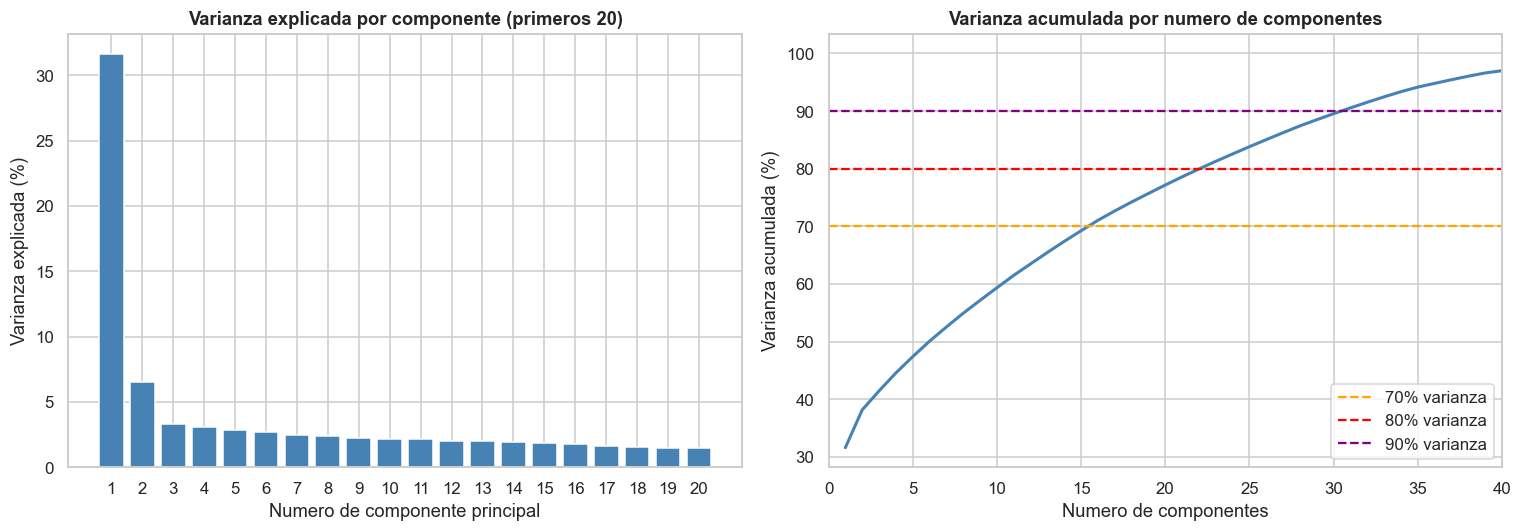

Componentes necesarios para explicar el 70% de la varianza: 16
Componentes necesarios para explicar el 80% de la varianza: 23
Componentes necesarios para explicar el 90% de la varianza: 31

Varianza explicada por los primeros 10 componentes:
  PC 1: 31.60%  (acumulada: 31.60%)
  PC 2: 6.55%  (acumulada: 38.15%)
  PC 3: 3.30%  (acumulada: 41.45%)
  PC 4: 3.11%  (acumulada: 44.56%)
  PC 5: 2.83%  (acumulada: 47.39%)
  PC 6: 2.68%  (acumulada: 50.08%)
  PC 7: 2.47%  (acumulada: 52.54%)
  PC 8: 2.39%  (acumulada: 54.93%)
  PC 9: 2.24%  (acumulada: 57.17%)
  PC10: 2.18%  (acumulada: 59.35%)


In [30]:
pca_full = PCA(random_state=42)
pca_full.fit(df_model)

var_exp = pca_full.explained_variance_ratio_
cumvar  = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 21), var_exp[:20] * 100, color='steelblue', edgecolor='white')
axes[0].set_title("Varianza explicada por componente (primeros 20)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Numero de componente principal")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_xticks(range(1, 21))

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, color='steelblue', linewidth=2)
axes[1].axhline(70, color='orange', linestyle='--', label='70% varianza')
axes[1].axhline(80, color='red',    linestyle='--', label='80% varianza')
axes[1].axhline(90, color='purple', linestyle='--', label='90% varianza')
axes[1].set_title("Varianza acumulada por numero de componentes", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Numero de componentes")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].legend()
axes[1].set_xlim(0, 40)

plt.tight_layout()
plt.show()

for threshold in [0.70, 0.80, 0.90]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f"Componentes necesarios para explicar el {int(threshold*100)}% de la varianza: {n}")

print()
print("Varianza explicada por los primeros 10 componentes:")
for i in range(10):
    print(f"  PC{i+1:2d}: {var_exp[i]*100:.2f}%  (acumulada: {cumvar[i]*100:.2f}%)")

**Resultado:** El primer componente principal explica el 31.6% de la varianza total, una proporcion alta que indica que existe una dimension dominante en los datos (interpretable como satisfaccion general). El segundo componente agrega 6.55%, y a partir del tercero la contribucion individual cae rapidamente por debajo del 4%. Para capturar el 70% de la varianza se necesitan 16 componentes; para el 80% se necesitan 23 y para el 90% se necesitan 31. Esta caida gradual (sin un codo claro) sugiere que los datos no tienen una estructura de muy baja dimension, lo que es esperable dado el caracter multidimensional de la experiencia de compra. Para la visualizacion 2D se usaran los dos primeros componentes, que juntos explican el 38.15% de la varianza.


#### 4.1.2 Interpretacion de los componentes principales

Se identifican las variables que mas contribuyen a cada componente principal (loadings). Esto permite darle un nombre o interpretacion al eje de cada componente, convirtiendo una tecnica matematica en un instrumento de analisis de negocio.


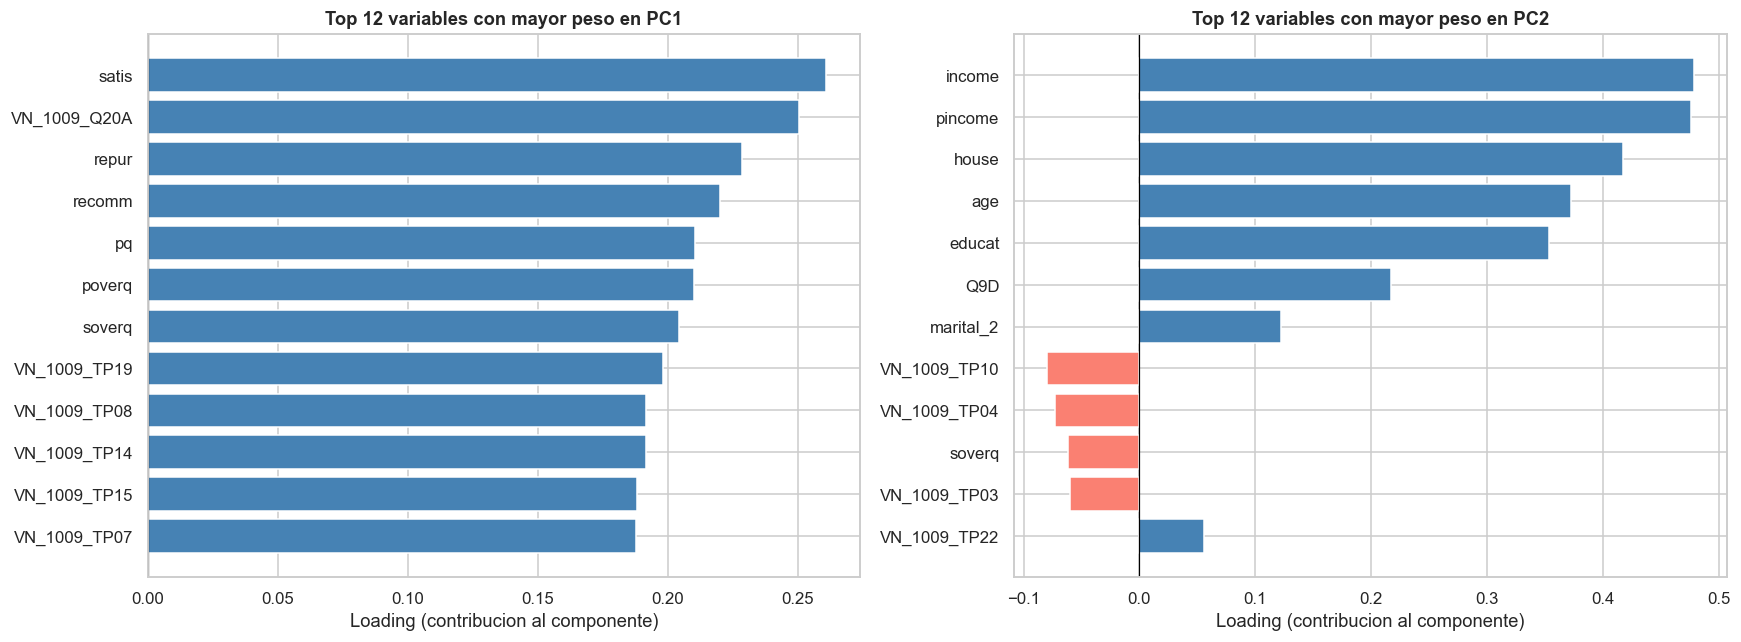

Top 8 variables por loading absoluto en PC1:
satis          0.26
VN_1009_Q20A   0.25
repur          0.23
recomm         0.22
pq             0.21
poverq         0.21
soverq         0.20
VN_1009_TP19   0.20

Top 8 variables por loading absoluto en PC2:
income         0.48
pincome        0.48
house          0.42
age            0.37
educat         0.35
Q9D            0.22
marital_2      0.12
VN_1009_TP10   0.08


In [31]:
pca_2 = PCA(n_components=2, random_state=42)
pca_coords = pca_2.fit_transform(df_model)

loadings = pd.DataFrame(
    pca_2.components_.T,
    index=df_model.columns,
    columns=['PC1', 'PC2']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pc in zip(axes, ['PC1', 'PC2']):
    top = loadings[pc].abs().sort_values(ascending=False).head(12)
    vals = loadings[pc].loc[top.index]
    colors = ['steelblue' if v > 0 else 'salmon' for v in vals]
    ax.barh(top.index, vals, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"Top 12 variables con mayor peso en {pc}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Loading (contribucion al componente)")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("Top 8 variables por loading absoluto en PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(8).round(3).to_string())
print()
print("Top 8 variables por loading absoluto en PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(8).round(3).to_string())

**Resultado:** El PC1 esta dominado por variables de satisfaccion general y percepciones globales (satis: 0.261, VN_1009_Q20A: 0.250, repur: 0.229, recomm: 0.220), seguidas de los touchpoints de la experiencia completa. Este eje puede interpretarse como el nivel general de satisfaccion con la plataforma: valores altos indican clientes muy satisfechos y valores bajos indican clientes insatisfechos o criticos.

El PC2 esta determinado principalmente por variables socioeconomicas y demograficas (income: 0.479, pincome: 0.476, house: 0.417, age: 0.372, educat: 0.354). Este eje representa el nivel socioeconomico del cliente: valores altos corresponden a clientes de mayor ingreso, mayor edad y mejor vivienda.

Esta separacion entre un eje de satisfaccion y un eje de perfil socioeconomico es coherente con la teoria: los dos factores que mas diferencian a los clientes de e-commerce son (1) que tan satisfechos estan con el servicio y (2) quien es el cliente en terminos de capacidad de compra.


#### 4.1.3 Visualizacion PCA en 2D

Se proyectan las 1.600 observaciones en el plano definido por los dos primeros componentes principales. Se colorea por la variable satis para verificar si el eje de satisfaccion (PC1) discrimina efectivamente entre clientes con distintos niveles de satisfaccion.


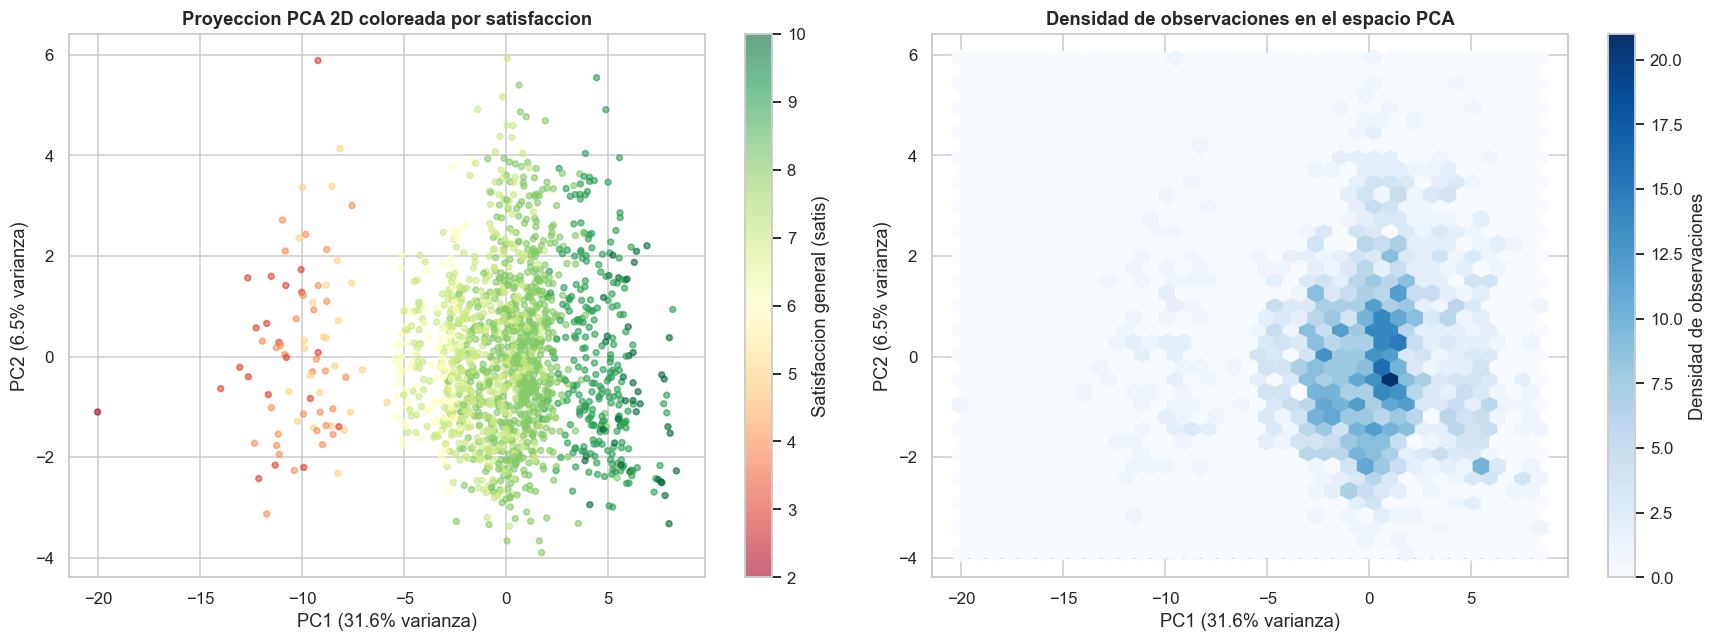

Varianza total explicada por PC1 + PC2: 38.15%


In [32]:
df_pca_plot = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
df_pca_plot['satis'] = df['satis'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_pca_plot['PC1'], df_pca_plot['PC2'],
                     c=df_pca_plot['satis'], cmap='RdYlGn', alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[0], label='Satisfaccion general (satis)')
axes[0].set_title("Proyeccion PCA 2D coloreada por satisfaccion", fontsize=12, fontweight='bold')
axes[0].set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% varianza)")
axes[0].set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% varianza)")

# Hexbin para densidad
hb = axes[1].hexbin(df_pca_plot['PC1'], df_pca_plot['PC2'], gridsize=35, cmap='Blues')
plt.colorbar(hb, ax=axes[1], label='Densidad de observaciones')
axes[1].set_title("Densidad de observaciones en el espacio PCA", fontsize=12, fontweight='bold')
axes[1].set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% varianza)")
axes[1].set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% varianza)")

plt.tight_layout()
plt.show()

print(f"Varianza total explicada por PC1 + PC2: {sum(pca_2.explained_variance_ratio_)*100:.2f}%")

**Resultado:** La proyeccion PCA muestra un gradiente claro a lo largo del eje PC1: los puntos de color verde (alta satisfaccion) se concentran en valores positivos de PC1, mientras los puntos rojos (baja satisfaccion) tienden a valores negativos. Esto confirma que PC1 captura efectivamente el nivel de satisfaccion general.

Sin embargo, la nube de puntos no presenta clusters claramente delimitados: los datos forman una estructura continua y densa sin separaciones evidentes. Esto es caracteristico de PCA cuando los datos no tienen estructura de baja dimension con fronteras nitidas. El mapa de densidad revela que la mayor concentracion de observaciones esta en la zona central-derecha del espacio (clientes moderadamente satisfechos con perfil socioeconomico medio).

Esta ausencia de clusters visibles en PCA no significa que no existan grupos: PCA solo captura estructura lineal. UMAP, al capturar relaciones no lineales, podria revelar separaciones que PCA no puede mostrar.


**Resultado:** El biplot confirma la interpretacion de los ejes. Las variables de satisfaccion (satis, poverq, repur, recomm) apuntan hacia la derecha (valores positivos de PC1), indicando que los clientes en esa zona son los mas satisfechos. Las variables socioeconomicas (income, pincome, house, age) apuntan hacia arriba (valores positivos de PC2), identificando a los clientes de mayor poder adquisitivo. La longitud de cada flecha indica la magnitud de la contribucion: flechas largas como la de satis e income senalan las variables con mayor peso en los respectivos componentes.


### 4.2 UMAP - Modelo avanzado

#### 4.2.1 Concepto y parametros

UMAP (Uniform Manifold Approximation and Projection) es una tecnica de reduccion de dimensionalidad no lineal que asume que los datos yacen en una variedad de baja dimension dentro del espacio de alta dimension. A diferencia de PCA, UMAP puede capturar relaciones no lineales complejas y tiende a preservar mejor la estructura local (vecindades) y global (separacion entre grupos distantes).

Los dos parametros mas importantes son:
- **n_neighbors (30):** controla el equilibrio entre estructura local y global. Valores bajos preservan estructura local fina; valores altos revelan la estructura global. Se elige 30 para obtener un balance adecuado con 1.600 observaciones.
- **min_dist (0.1):** controla que tan compactos son los clusters en la proyeccion. Valores bajos generan clusters mas densos y separados; valores altos producen una distribucion mas uniforme. Se elige 0.1 para facilitar la identificacion visual de grupos.


In [34]:
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(df_model)

df_umap = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
df_umap['satis'] = df['satis'].values

print(f"Dimensiones de la proyeccion UMAP: {embedding.shape}")
print(f"Rango UMAP1: [{embedding[:,0].min():.2f}, {embedding[:,0].max():.2f}]")
print(f"Rango UMAP2: [{embedding[:,1].min():.2f}, {embedding[:,1].max():.2f}]")

Dimensiones de la proyeccion UMAP: (1600, 2)
Rango UMAP1: [4.09, 10.91]
Rango UMAP2: [10.35, 19.50]


#### 4.2.2 Visualizacion UMAP coloreada por satisfaccion

Se proyectan las 1.600 observaciones en el espacio 2D de UMAP, coloreando por el nivel de satisfaccion general. Esto permite verificar si UMAP revela agrupaciones mas claras que PCA y si la separacion por satisfaccion es mas nitida.


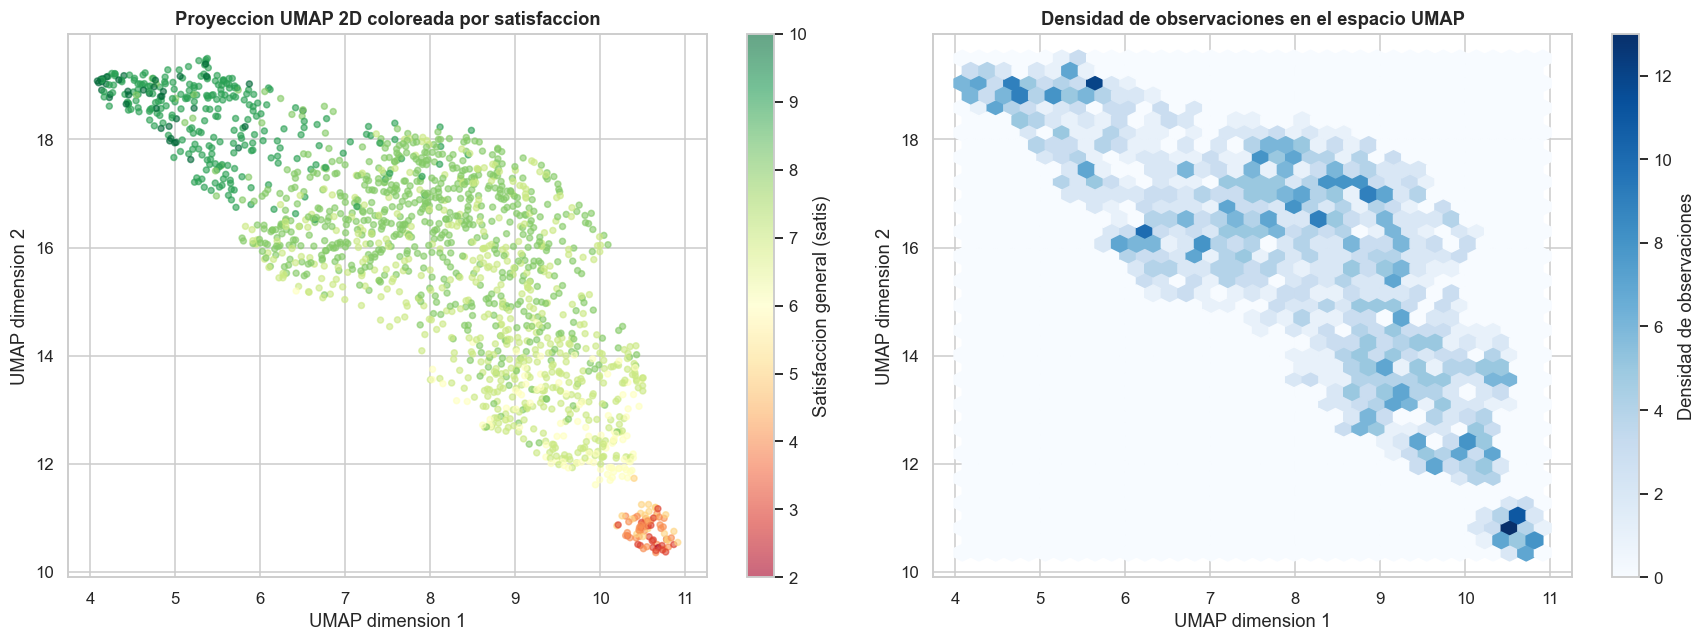

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_umap['UMAP1'], df_umap['UMAP2'],
                     c=df_umap['satis'], cmap='RdYlGn', alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[0], label='Satisfaccion general (satis)')
axes[0].set_title("Proyeccion UMAP 2D coloreada por satisfaccion", fontsize=12, fontweight='bold')
axes[0].set_xlabel("UMAP dimension 1")
axes[0].set_ylabel("UMAP dimension 2")

hb = axes[1].hexbin(df_umap['UMAP1'], df_umap['UMAP2'], gridsize=35, cmap='Blues')
plt.colorbar(hb, ax=axes[1], label='Densidad de observaciones')
axes[1].set_title("Densidad de observaciones en el espacio UMAP", fontsize=12, fontweight='bold')
axes[1].set_xlabel("UMAP dimension 1")
axes[1].set_ylabel("UMAP dimension 2")

plt.tight_layout()
plt.show()

**Resultado:** La proyeccion UMAP revela una estructura mas rica que PCA. Se observa una nube principal densa con subregiones de diferente concentracion, y un conjunto de puntos algo separados en la periferia. El gradiente de satisfaccion es visible pero con un patron diferente al de PCA: en lugar de un gradiente lineal continuo, UMAP muestra zonas con mayor concentracion de clientes muy satisfechos (verde) y zonas con clientes de satisfaccion moderada (amarillo-naranja), con los clientes menos satisfechos (rojo) dispersos en los bordes. Esta estructura sugiere que hay grupos con perfiles diferenciados que el clustering podra capturar.


#### 4.2.3 UMAP coloreado por variables demograficas

Se visualiza la misma proyeccion UMAP coloreada por diferentes variables para identificar que factores explican la estructura observada y cuales podrian ser las dimensiones que definen los clusters.


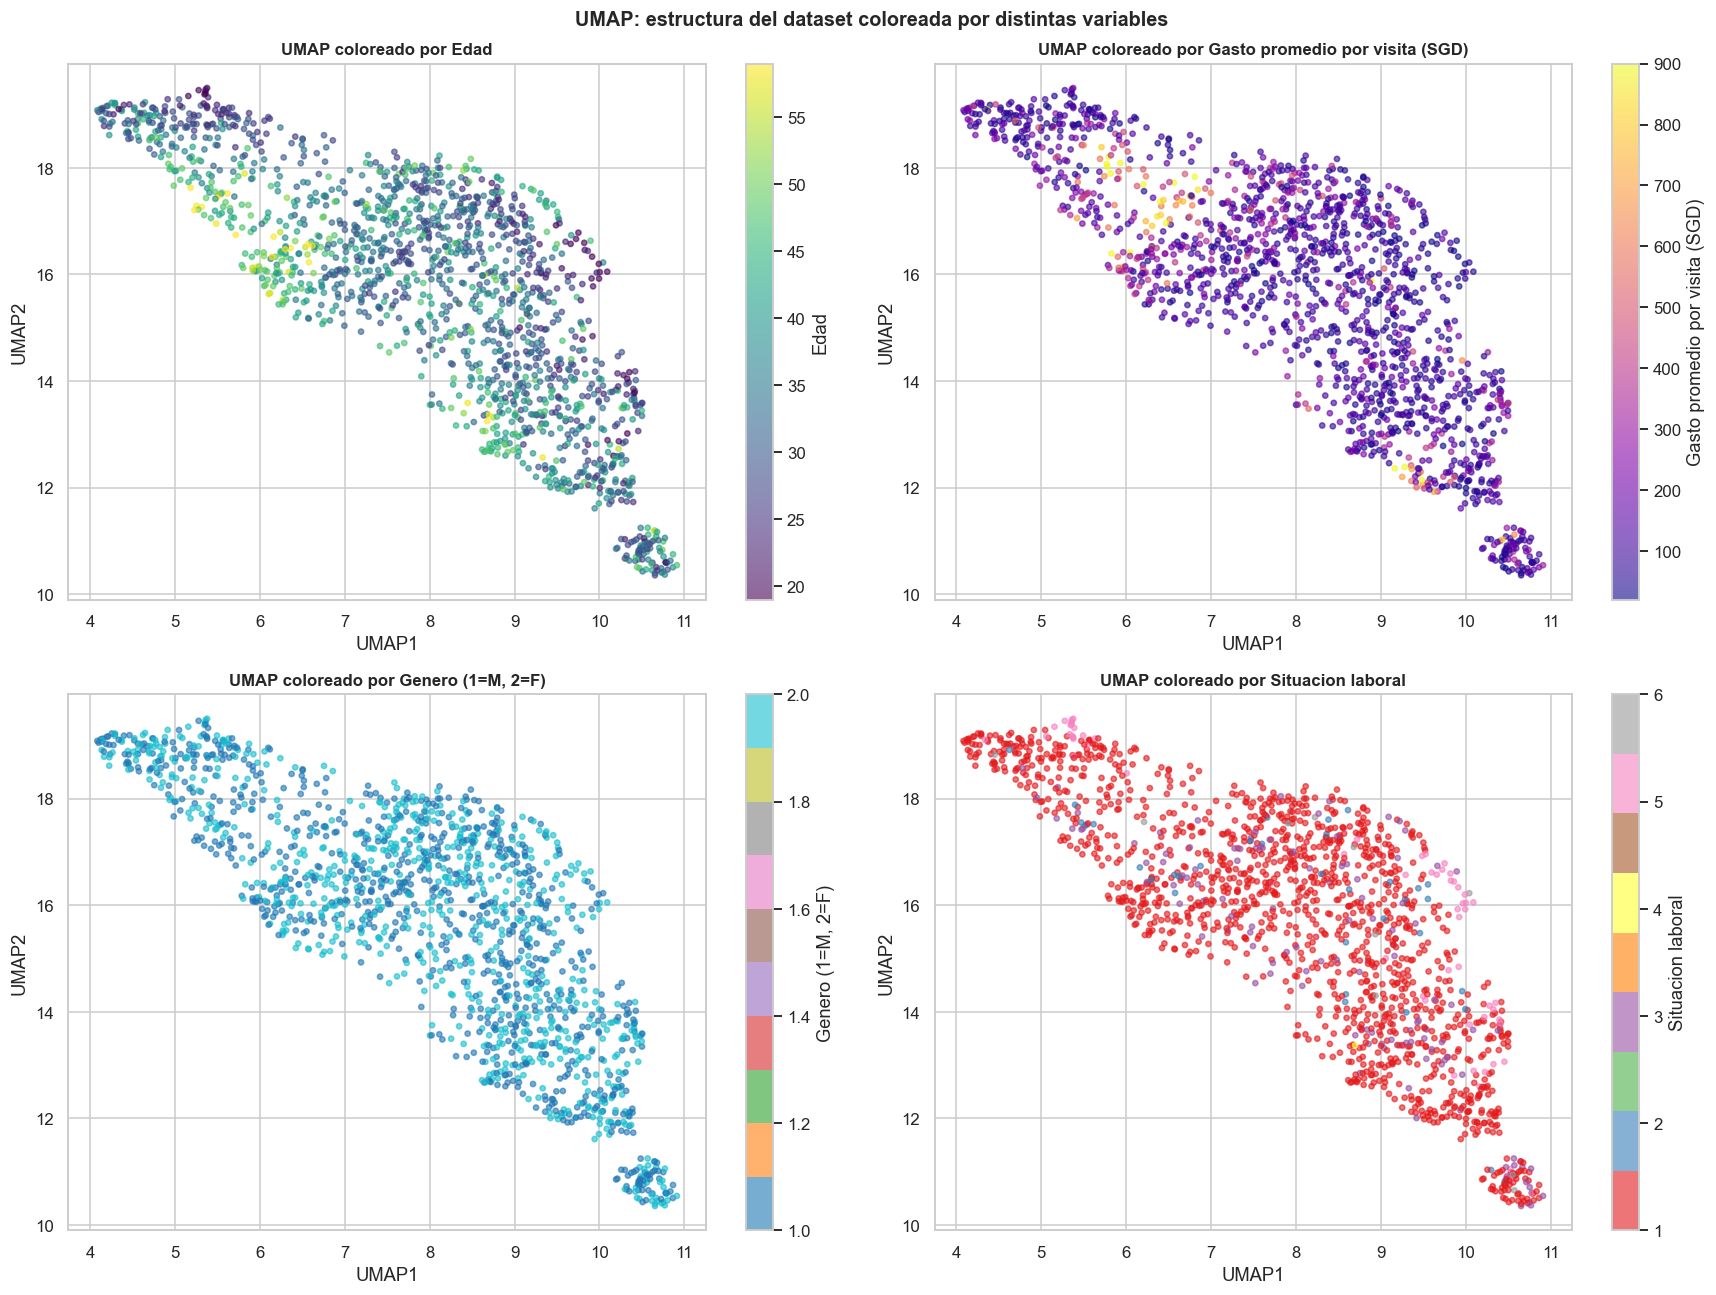

In [36]:
vars_color = {
    'age': ('Edad', 'viridis'),
    'Q9D': ('Gasto promedio por visita (SGD)', 'plasma'),
}

# Variables categoricas del dataframe original
vars_cat_color = {
    'gender': ('Genero (1=M, 2=F)', 'tab10'),
    'work':   ('Situacion laboral', 'Set1'),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

idx = 0
for col, (titulo, cmap) in vars_color.items():
    sc = axes[idx].scatter(df_umap['UMAP1'], df_umap['UMAP2'],
                           c=df[col].values, cmap=cmap, alpha=0.6, s=12)
    plt.colorbar(sc, ax=axes[idx], label=titulo)
    axes[idx].set_title(f"UMAP coloreado por {titulo}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("UMAP1")
    axes[idx].set_ylabel("UMAP2")
    idx += 1

for col, (titulo, cmap) in vars_cat_color.items():
    sc = axes[idx].scatter(df_umap['UMAP1'], df_umap['UMAP2'],
                           c=df[col].values, cmap=cmap, alpha=0.6, s=12)
    plt.colorbar(sc, ax=axes[idx], label=titulo)
    axes[idx].set_title(f"UMAP coloreado por {titulo}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("UMAP1")
    axes[idx].set_ylabel("UMAP2")
    idx += 1

plt.suptitle("UMAP: estructura del dataset coloreada por distintas variables", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Resultado:** Las visualizaciones de UMAP coloreadas por distintas variables revelan que la edad y el gasto promedio muestran gradientes visibles dentro de la proyeccion, confirmando que las variables socioeconomicas contribuyen a la estructura observada. El genero no muestra un patron geografico claro en la proyeccion, lo que sugiere que no es una variable determinante para la formacion de clusters. La situacion laboral si muestra cierta agrupacion, con trabajadores a tiempo completo concentrados en zonas especificas de la proyeccion. Estas observaciones orientan la interpretacion que se hara de los clusters en la siguiente fase del proyecto.


### 4.3 Comparacion PCA vs UMAP

Se presentan las dos proyecciones lado a lado para comparar directamente lo que cada tecnica revela sobre la estructura de los datos.


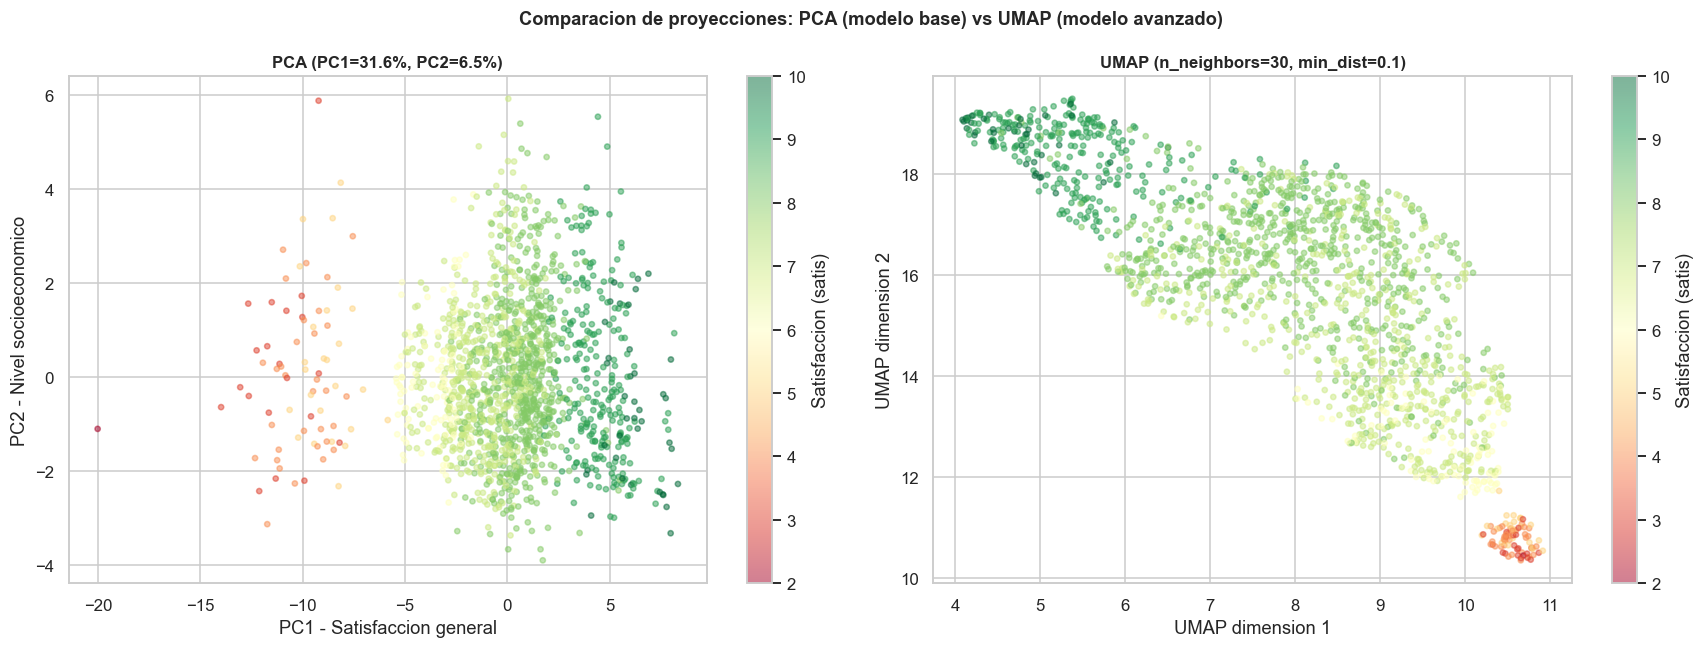

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(df_pca_plot['PC1'], df_pca_plot['PC2'],
                      c=df_pca_plot['satis'], cmap='RdYlGn', alpha=0.5, s=12)
plt.colorbar(sc1, ax=axes[0], label='Satisfaccion (satis)')
axes[0].set_title(f"PCA (PC1={pca_2.explained_variance_ratio_[0]*100:.1f}%, PC2={pca_2.explained_variance_ratio_[1]*100:.1f}%)",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel("PC1 - Satisfaccion general")
axes[0].set_ylabel("PC2 - Nivel socioeconomico")

sc2 = axes[1].scatter(df_umap['UMAP1'], df_umap['UMAP2'],
                      c=df_umap['satis'], cmap='RdYlGn', alpha=0.5, s=12)
plt.colorbar(sc2, ax=axes[1], label='Satisfaccion (satis)')
axes[1].set_title("UMAP (n_neighbors=30, min_dist=0.1)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("UMAP dimension 1")
axes[1].set_ylabel("UMAP dimension 2")

plt.suptitle("Comparacion de proyecciones: PCA (modelo base) vs UMAP (modelo avanzado)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Resultado y comparacion:**

PCA produce una proyeccion con interpretacion directa: los ejes tienen significado (satisfaccion y nivel socioeconomico) y el gradiente de satisfaccion es lineal y claro. Sin embargo, la nube de puntos es compacta y no muestra separaciones nitidas, lo que dificulta identificar cuantos grupos existen y donde estan sus fronteras.

UMAP revela una estructura mas compleja con subregiones de distinta densidad y algunos puntos alejados de la masa principal. Aunque los ejes no son interpretables directamente, la distribucion sugiere que existen al menos dos o tres zonas diferenciadas que el algoritmo de clustering podra capturar.

La principal conclusion de esta seccion es que los datos tienen una estructura no trivial: no hay clusters perfectamente separados (lo que es habitual en datos de encuestas), pero si hay zonas de mayor y menor densidad que justifican el uso de clustering. UMAP sera mas util como soporte visual para la interpretacion de los clusters que PCA, que seguira siendo valioso por su interpretabilidad de los componentes.

La siguiente etapa del proyecto aplicara algoritmos de clustering (K-Means y/o DBSCAN) sobre el espacio completo preprocesado, usando las proyecciones de PCA y UMAP como herramientas de visualizacion y validacion de los grupos encontrados.


### Punto 3

### Punto 4